/global/u1/h/hugon/home/acm
COV KEYS: ['cosmo_id', 'phase_id', 'seed_id', 'params', 's', 'ds_z', 'ds_r', 'ds_rand', 'pcf', 'counts_r', 'counts_z', 'counts_rand', 'label_r', 'label_z', 'label_rand', 'transition', 'pos_sample', 'pos_r_sample', 'gal_idx_sample', 'label_r_sample', 'label_z_sample', 'rvals_r_sample', 'rvals_z_sample', 'rvals_r', 'rvals_z', 'rvals_rand']
DERIV KEYS: ['cosmo_id', 'phase_id', 'seed_id', 'params', 's', 'ds_z', 'ds_r', 'ds_rand', 'pcf', 'counts_r', 'counts_z', 'counts_rand', 'label_r', 'label_z', 'label_rand', 'transition', 'pos_sample', 'pos_r_sample', 'gal_idx_sample', 'label_r_sample', 'label_z_sample', 'rvals_r_sample', 'rvals_z_sample', 'rvals_r', 'rvals_z', 'rvals_rand']
nb bins = 25
Covariance shape: (50, 50)
Computed derivatives: ['omega_b', 'omega_cdm', 'n_s', 'sigma8_m']
derivatives shape (400,)


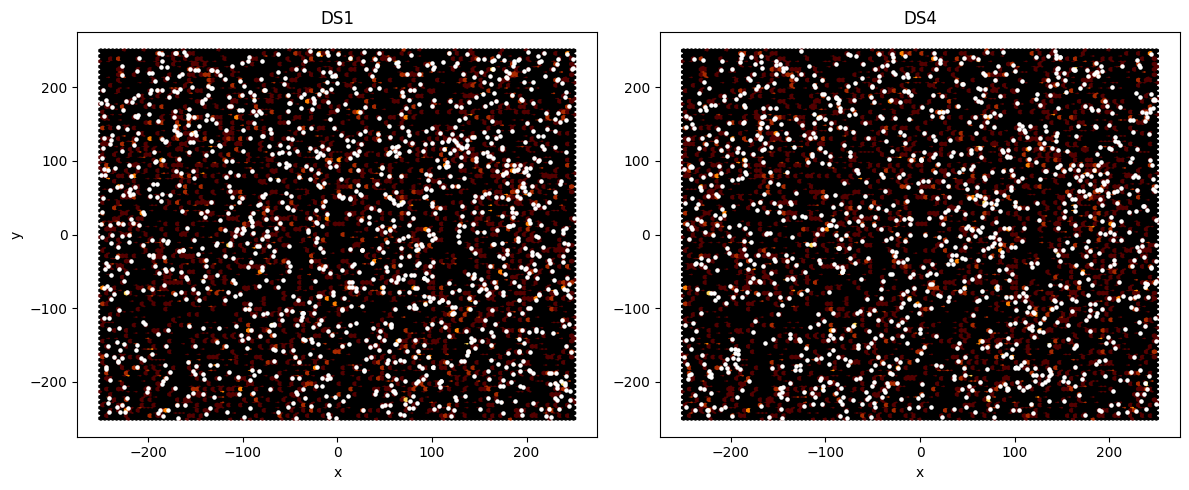

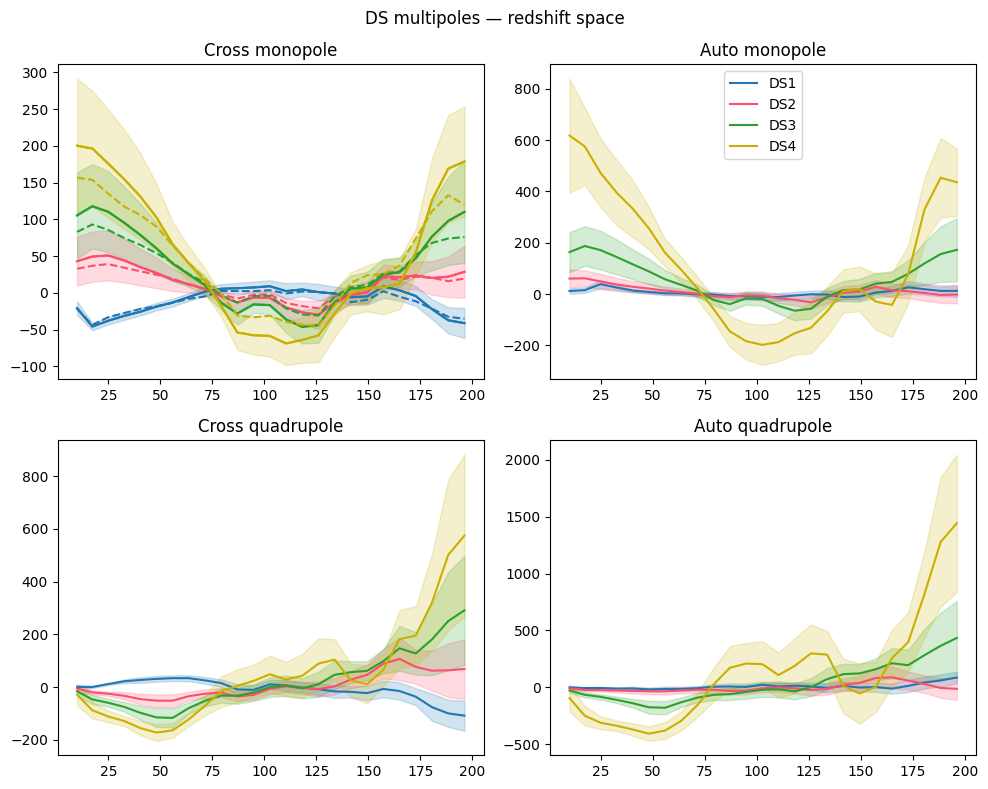

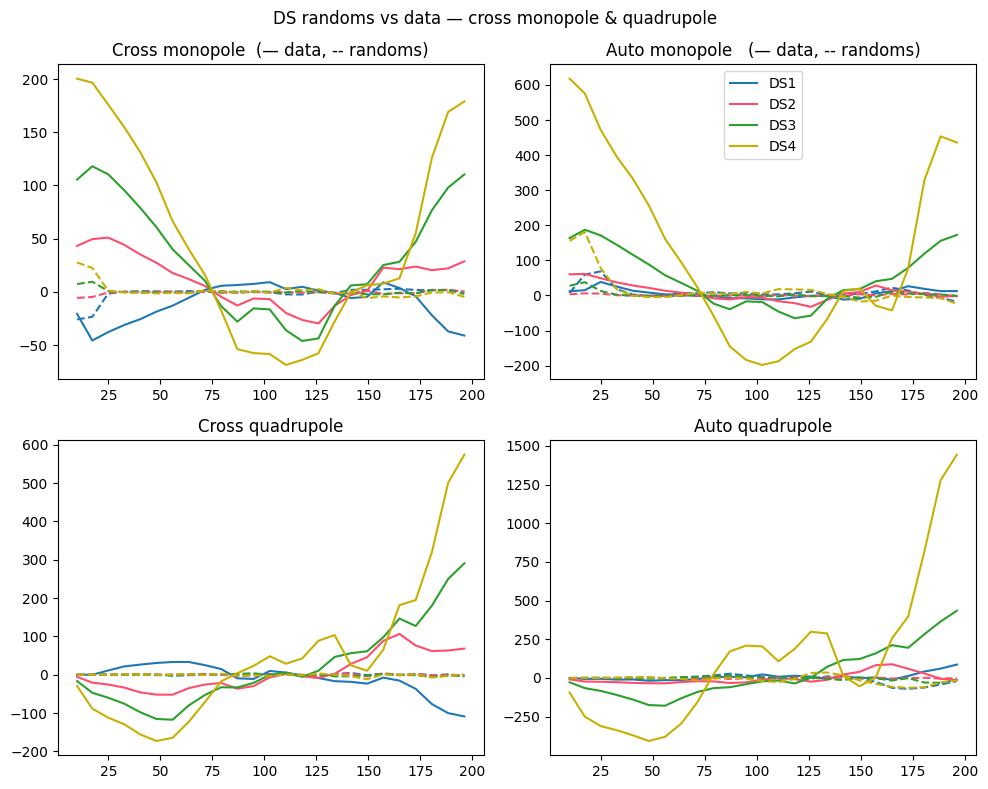

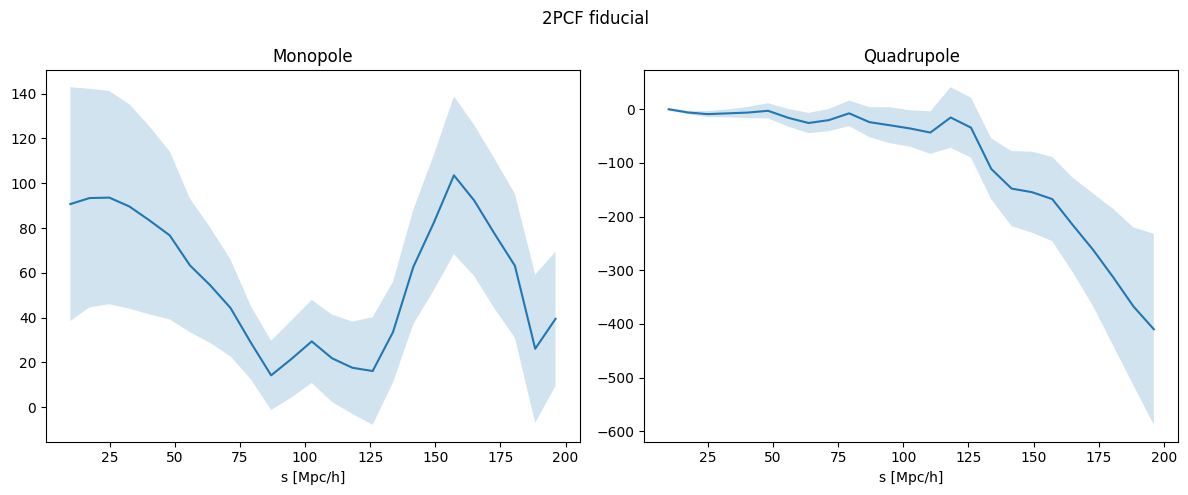

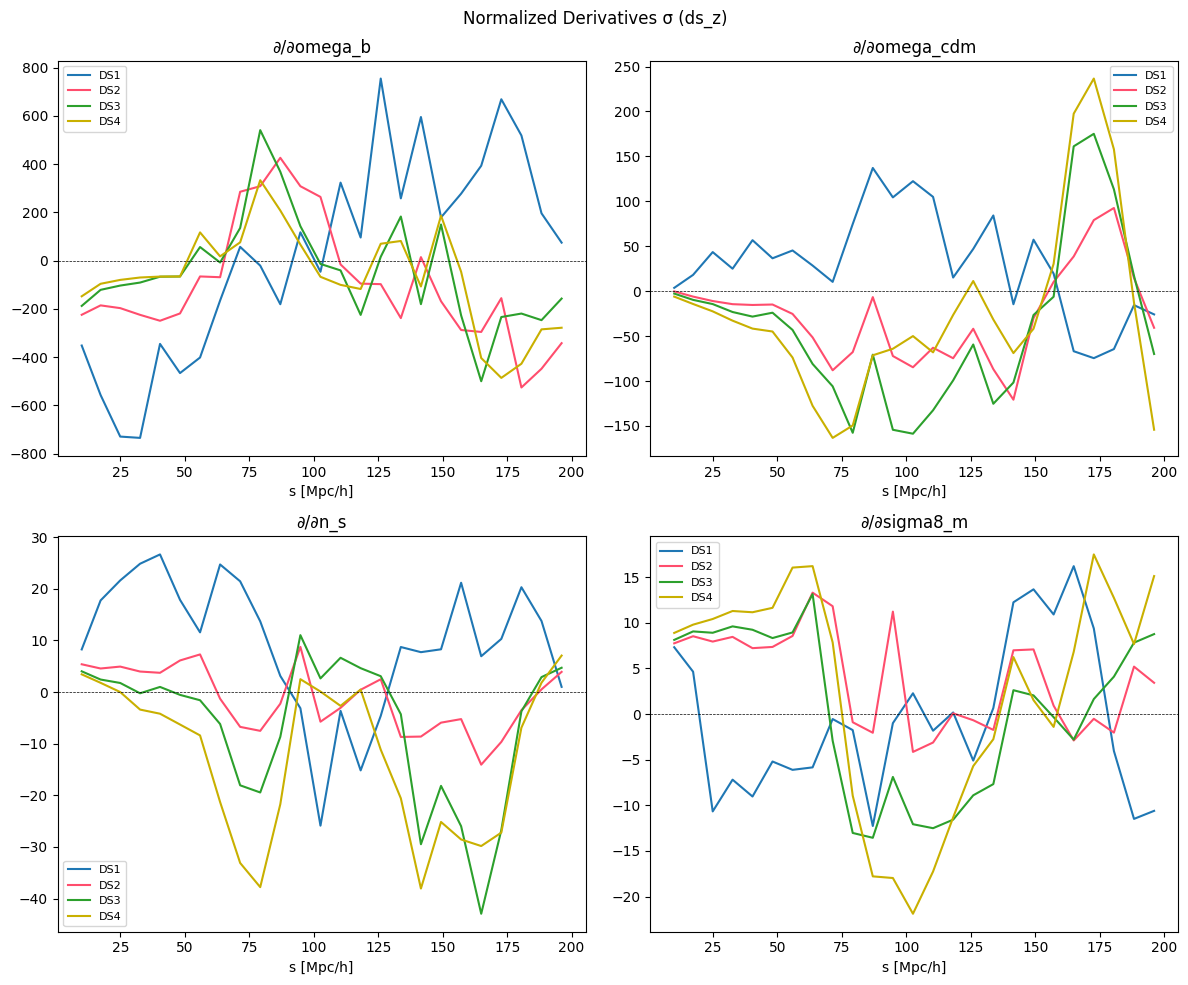


=== QUANTILE BALANCE ===
DS1: 0.255
DS2: 0.254
DS3: 0.250
DS4: 0.241

=== SHAPES ===
pcf shape: (500, 50)
ds_z shape: (500, 400)
ds_rand shape: (500, 400)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# LOAD
# ============================================================
%cd /global/homes/h/hugon/home/acm

# data_cov   = np.load("dataset_covariance_astra_32_1_250.npz", allow_pickle=True)
# data_deriv = np.load("dataset_derivatives_astra_32_1_250.npz", allow_pickle=True)
# data_cov   = np.load("dataset_covariance_astra_1_1_1000.0.npz", allow_pickle=True)
# data_deriv = np.load("dataset_derivatives_astra_1_1_1000.0.npz", allow_pickle=True)

data_cov   = np.load("dataset_covariance_astra_1500_1_250_200.npz", allow_pickle=True)
data_deriv = np.load("dataset_derivatives_astra_64_1_250_200.npz", allow_pickle=True)
COSMOLOGY_FILE = "/global/homes/h/hugon/home/acm/nb/cosmologies.csv"

cosmo_df = pd.read_csv(COSMOLOGY_FILE)
cosmo_df.columns = cosmo_df.columns.str.strip()
cosmo_df["cosmo_id"] = cosmo_df["cosmo_id"] = cosmo_df["root"].str.extract(r"cosm(\d+)").astype(int)
cosmo_df = cosmo_df.set_index("cosmo_id")

print("COV KEYS:",   data_cov.files)
print("DERIV KEYS:", data_deriv.files)

FID_COSMO = 0

# ============================================================
# HELPERS
# ============================================================

def stack(arr):
    return np.vstack([np.asarray(x, dtype=float) for x in arr])

def group_by_cosmo(data):
    grouped = {}
    for i, cid in enumerate(data["cosmo_id"]):
        grouped.setdefault(int(cid), []).append(i)
    return grouped

def get_block(vec, i, nb):
    return vec[i*nb:(i+1)*nb]

# ============================================================
# BASIC ARRAYS
# ============================================================

s  = np.asarray(data_cov["s"][0], dtype=float)
nb = len(s)
print("nb bins =", nb)

group_cov   = group_by_cosmo(data_cov)
group_deriv = group_by_cosmo(data_deriv)
idx_fid     = group_cov[FID_COSMO]

# ============================================================
# COVARIANCE
# ============================================================

'''
For Fisher Matrices, we need the same observable vector for both the covariance and the derivatives.
'''

X        = stack(data_cov["pcf"][idx_fid])
mean_pcf = X.mean(axis=0)
cov      = np.cov(X, rowvar=False)
std_pcf  = np.sqrt(np.diag(cov))

print("Covariance shape:", cov.shape)

# ============================================================
# DS MEAN
# ============================================================

ds_z   = stack(data_cov["ds_z"][idx_fid])
ds_r   = stack(data_cov["ds_r"][idx_fid])
ds_rand= stack(data_cov["ds_rand"][idx_fid])

mean_z    = ds_z.mean(axis=0)
std_z     = ds_z.std(axis=0)
mean_r    = ds_r.mean(axis=0)
std_r     = ds_r.std(axis=0)
mean_rand = ds_rand.mean(axis=0)
std_rand  = ds_rand.std(axis=0)

# ============================================================
# DERIVATIVES
# ============================================================

FEATURE_COLS = ["omega_b", "omega_cdm", "h", "A_s", "n_s", "sigma8_m", "sigma8_cb"]

pairs = {
    "omega_b":   (100, 101),
    "omega_cdm": (102, 103),
    "n_s":       (104, 105),
    "sigma8_m":  (112, 113),
}

derivatives = {}

for pname, (cp, cm) in pairs.items():

    if cp not in group_deriv or cm not in group_deriv:
        print(f"Skipping {pname}")
        continue

    Xp = stack(data_deriv["ds_z"][group_deriv[cp]]).mean(axis=0)
    Xm = stack(data_deriv["ds_z"][group_deriv[cm]]).mean(axis=0)

    delta         = cosmo_df.loc[cp, pname] - cosmo_df.loc[cm, pname]
    derivatives[pname] = (Xp - Xm) / delta

print("Computed derivatives:", list(derivatives.keys()))
print("derivatives shape", derivatives[pname].shape)

# ============================================================
# FIGURE 1 — spatial distribution DS1 vs DS4
# ============================================================

pos = np.asarray(data_cov["pos_sample"][idx_fid[0]])
lab = np.asarray(data_cov["label_z"][idx_fid[0]])[:len(pos)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, q, title in zip(axes, [0, 3], ["DS1", "DS4"]):
    mask = lab == q
    ax.hexbin(pos[:, 0], pos[:, 1], gridsize=120, cmap="afmhot")
    ax.scatter(pos[mask, 0], pos[mask, 1], s=5, c="white")
    ax.set_title(title)
    ax.set_xlabel("x")

axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 2 — DS multipoles (redshift space)
# ============================================================

colors = ["#1f77b4", "#ff4d6d", "#2ca02c", "#c9b000"]
labels = ["DS1", "DS2", "DS3", "DS4"]

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("DS multipoles — redshift space")

for q in range(4):

    mono_z = get_block(mean_z, 2*q, nb)
    mono_r = get_block(mean_r, 2*q, nb)

    quad_z = get_block(mean_z, 2*q+1, nb)
    quad_r = get_block(mean_r, 2*q+1, nb)

    ax[0, 0].plot(s, s**2 * mono_z, color=colors[q], label=f"{labels[q]} z")
    ax[0, 0].plot(s, s**2 * mono_r, color=colors[q], linestyle="--", label=f"{labels[q]} r")

    mono = get_block(mean_z, 2*q,   nb)
    quad = get_block(mean_z, 2*q+1, nb)
    err_mono = get_block(std_z, 2*q,   nb)
    err_quad = get_block(std_z, 2*q+1, nb)

    ax[0, 0].plot(s, s**2 * mono, color=colors[q], label=labels[q])
    ax[0, 0].fill_between(s, s**2*(mono-err_mono), s**2*(mono+err_mono), alpha=0.2, color=colors[q])

    ax[1, 0].plot(s, s**2 * quad, color=colors[q])
    ax[1, 0].fill_between(s, s**2*(quad-err_quad), s**2*(quad+err_quad), alpha=0.2, color=colors[q])

for q in range(4):
    mono = get_block(mean_z, 8+2*q,   nb)
    quad = get_block(mean_z, 8+2*q+1, nb)
    err_mono = get_block(std_z, 8+2*q,   nb)
    err_quad = get_block(std_z, 8+2*q+1, nb)

    ax[0, 1].plot(s, s**2 * mono, color=colors[q], label=labels[q])
    ax[0, 1].fill_between(s, s**2*(mono-err_mono), s**2*(mono+err_mono), alpha=0.2, color=colors[q])

    ax[1, 1].plot(s, s**2 * quad, color=colors[q])
    ax[1, 1].fill_between(s, s**2*(quad-err_quad), s**2*(quad+err_quad), alpha=0.2, color=colors[q])

ax[0, 0].set_title("Cross monopole")
ax[0, 1].set_title("Auto monopole")
ax[1, 0].set_title("Cross quadrupole")
ax[1, 1].set_title("Auto quadrupole")
ax[0, 1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 3 — DS randoms vs data
# ============================================================

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("DS randoms vs data — cross monopole & quadrupole")

for q in range(4):
    mono_z    = get_block(mean_z,    2*q,   nb)
    mono_rand = get_block(mean_rand, 2*q,   nb)
    quad_z    = get_block(mean_z,    2*q+1, nb)
    quad_rand = get_block(mean_rand, 2*q+1, nb)

    ax[0, 0].plot(s, s**2 * mono_z,    color=colors[q], label=labels[q])
    ax[0, 0].plot(s, s**2 * mono_rand, color=colors[q], linestyle="--")

    ax[1, 0].plot(s, s**2 * quad_z,    color=colors[q])
    ax[1, 0].plot(s, s**2 * quad_rand, color=colors[q], linestyle="--")

for q in range(4):
    mono_z    = get_block(mean_z,    8+2*q,   nb)
    mono_rand = get_block(mean_rand, 8+2*q,   nb)
    quad_z    = get_block(mean_z,    8+2*q+1, nb)
    quad_rand = get_block(mean_rand, 8+2*q+1, nb)

    ax[0, 1].plot(s, s**2 * mono_z,    color=colors[q], label=labels[q])
    ax[0, 1].plot(s, s**2 * mono_rand, color=colors[q], linestyle="--")

    ax[1, 1].plot(s, s**2 * quad_z,    color=colors[q])
    ax[1, 1].plot(s, s**2 * quad_rand, color=colors[q], linestyle="--")

ax[0, 0].set_title("Cross monopole  (— data, -- randoms)")
ax[0, 1].set_title("Auto monopole   (— data, -- randoms)")
ax[1, 0].set_title("Cross quadrupole")
ax[1, 1].set_title("Auto quadrupole")
ax[0, 1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 4 — 2PCF
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("2PCF fiducial")

axes[0].plot(s, s**2 * mean_pcf[:nb])
axes[0].fill_between(s, s**2*(mean_pcf[:nb]-std_pcf[:nb]),
                        s**2*(mean_pcf[:nb]+std_pcf[:nb]), alpha=0.2)
axes[0].set_title("Monopole")
axes[0].set_xlabel("s [Mpc/h]")

axes[1].plot(s, s**2 * mean_pcf[nb:])
axes[1].fill_between(s, s**2*(mean_pcf[nb:]-std_pcf[nb:]),
                        s**2*(mean_pcf[nb:]+std_pcf[nb:]), alpha=0.2)
axes[1].set_title("Quadrupole")
axes[1].set_xlabel("s [Mpc/h]")

plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 5 — dérivées normalisées
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Normalized Derivatives σ (ds_z)")

for ax, pname in zip(axes.flat, pairs.keys()):

    if pname not in derivatives:
        continue

    D = derivatives[pname] / (std_z + 1e-8)

    for q in range(4):
        ax.plot(s, get_block(D, 2*q, nb), color=colors[q], label=labels[q])

    ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
    ax.set_title(f"∂/∂{pname}")
    ax.set_xlabel("s [Mpc/h]")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ============================================================
# SANITY CHECKS
# ============================================================

print("\n=== QUANTILE BALANCE ===")
labels_arr = np.concatenate(data_cov["label_r"][idx_fid])
for q in range(4):
    print(f"DS{q+1}: {np.mean(labels_arr == q):.3f}")

print("\n=== SHAPES ===")
print("pcf shape:", stack(data_cov["pcf"][idx_fid]).shape)
print("ds_z shape:", ds_z.shape)
print("ds_rand shape:", ds_rand.shape)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. CHECK INPUTS
# ============================================================

print("Cov shape:", cov.shape)

for k, v in derivatives.items():
    print(f"{k}: shape {np.shape(v)}")

# ============================================================
# 2. FLATTEN DERIVATIVES CONSISTENTLY
# ============================================================

params = list(derivatives.keys())
npar = len(params)

# on suppose que chaque dérivée a même shape que cov (ou broadcastable)
# sinon on force un flatten propre

flat_derivatives = {}

for p in params:
    d = np.array(derivatives[p])

    # IMPORTANT: on force 1D
    flat_derivatives[p] = d.reshape(-1)

    print(f"{p} flattened shape: {flat_derivatives[p].shape}")

# sanity check
N = flat_derivatives[params[0]].shape[0]
print("Flattened vector size:", N)

# ============================================================
# 3. INVERSE COVARIANCE (STABILIZED)
# ============================================================

C_inv = np.linalg.inv(cov + 1e-8 * np.eye(cov.shape[0]))

# ============================================================
# 4. FISHER MATRIX
# ============================================================

F = np.zeros((npar, npar))

for i, pi in enumerate(params):
    di = flat_derivatives[pi]

    for j, pj in enumerate(params):
        dj = flat_derivatives[pj]

        # Fisher: d_i^T C^{-1} d_j
        F[i, j] = di @ C_inv @ dj

print("\nFisher matrix:\n", F)

# ============================================================
# 5. PLOT FISHER
# ============================================================

plt.figure(figsize=(6,5))
sns.heatmap(
    F,
    xticklabels=params,
    yticklabels=params,
    cmap="viridis",
    annot=True
)
plt.title("Fisher matrix")
plt.tight_layout()
plt.show()

# ============================================================
# 6. COVARIANCE ON PARAMETERS
# ============================================================

# protection inversion
eigvals = np.linalg.eigvalsh(F)
print("Eigenvalues Fisher:", eigvals)

F_inv = np.linalg.pinv(F)

plt.figure(figsize=(6,5))
sns.heatmap(
    F_inv,
    xticklabels=params,
    yticklabels=params,
    cmap="coolwarm"
)
plt.title("Parameter covariance (F⁻¹)")
plt.tight_layout()
plt.show()

Cov shape: (50, 50)
omega_b: shape (400,)
omega_cdm: shape (400,)
n_s: shape (400,)
sigma8_m: shape (400,)
omega_b flattened shape: (400,)
omega_cdm flattened shape: (400,)
n_s flattened shape: (400,)
sigma8_m flattened shape: (400,)
Flattened vector size: 400


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 50 is different from 400)

/global/u1/h/hugon/home/acm
Nombre de réalisations fiduciales : 500

=== r stats ===
min=-1.000  max=1.000
mean=0.065  std=0.353
fraction r==0 : 0.078


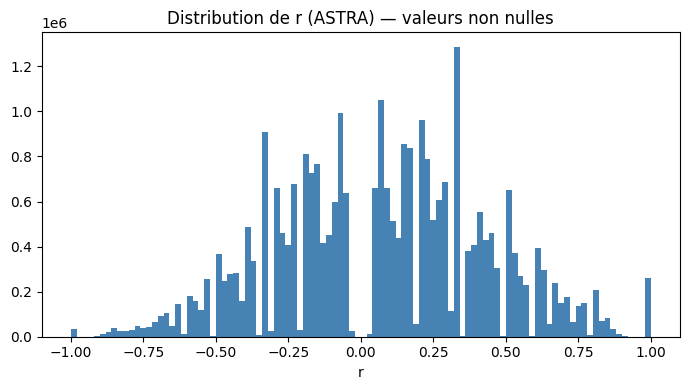


=== Balance quartiles (real space) ===
  DS1: 0.255
  DS2: 0.254
  DS3: 0.250
  DS4: 0.241

=== Balance quartiles (redshift space) ===
  DS1: 0.256
  DS2: 0.251
  DS3: 0.252
  DS4: 0.241

=== r moyen par quartile (real space) ===
  → DS1 doit être négatif, DS4 positif
  DS1: mean r = -0.3783  std = 0.1634
  DS2: mean r = -0.0448  std = 0.0783
  DS3: mean r = 0.1931  std = 0.0937
  DS4: mean r = 0.5160  std = 0.1803


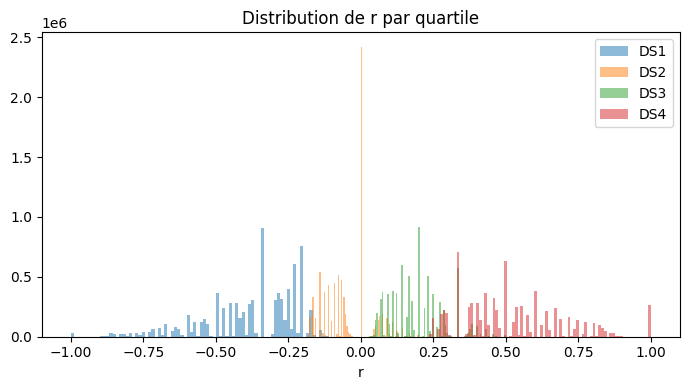

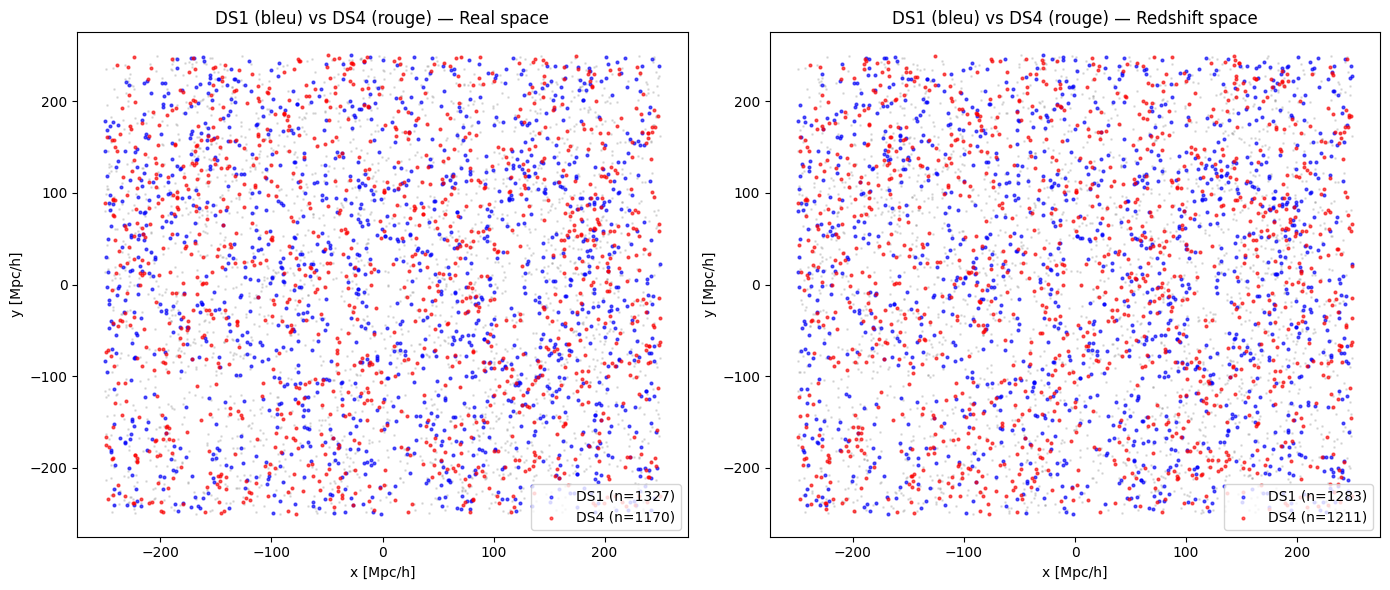


=== Counts moyens par quartile ===
  real space :     [15854 15830 15545 15023]
  redshift space : [15930 15627 15685 15010]


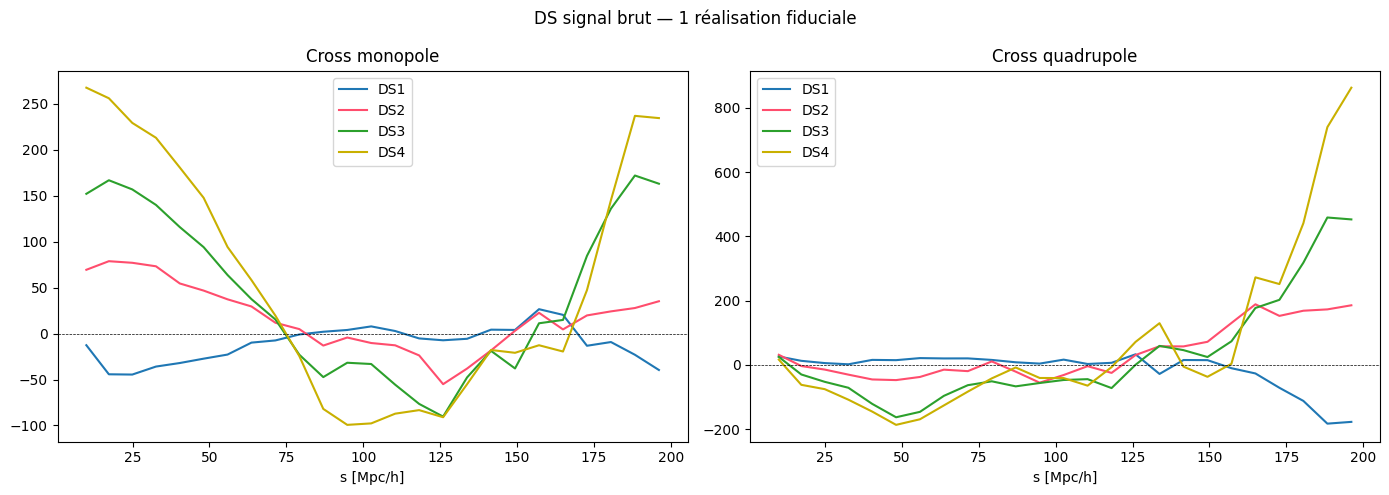


=== Taille vecteur ds_z ===
  attendu : 4 cross × 2 mult + 4 auto × 2 mult = 16 blocs × 25 bins = 400
  obtenu  : 400


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD
# ============================================================

%cd /global/homes/h/hugon/home/acm

data = np.load("dataset_covariance_astra_1500_1_250_200.npz", allow_pickle=True)

def stack(arr):
    return np.vstack([np.asarray(x, dtype=float) for x in arr])

def group_by_cosmo(data):
    grouped = {}
    for i, cid in enumerate(data["cosmo_id"]):
        grouped.setdefault(int(cid), []).append(i)
    return grouped

FID_COSMO = 0
group     = group_by_cosmo(data)
idx       = group[FID_COSMO]
print(f"Nombre de réalisations fiduciales : {len(idx)}")

# ============================================================
# 1. DISTRIBUTION DE r
# ============================================================

rvals_all = np.concatenate([np.asarray(data["rvals_r"][i]) for i in idx])
print(f"\n=== r stats ===")
print(f"min={rvals_all.min():.3f}  max={rvals_all.max():.3f}")
print(f"mean={rvals_all.mean():.3f}  std={rvals_all.std():.3f}")
print(f"fraction r==0 : {np.mean(rvals_all==0):.3f}")   # si > 0.5 → problème

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rvals_all[rvals_all != 0], bins=100, color="steelblue")
ax.set_title("Distribution de r (ASTRA) — valeurs non nulles")
ax.set_xlabel("r")
plt.tight_layout()
plt.show()

# ============================================================
# 2. BALANCE DES QUARTILES
# ============================================================

labels_r = np.concatenate([np.asarray(data["label_r"][i]) for i in idx])
labels_z = np.concatenate([np.asarray(data["label_z"][i]) for i in idx])

print(f"\n=== Balance quartiles (real space) ===")
for q in range(4):
    print(f"  DS{q+1}: {np.mean(labels_r == q):.3f}")

print(f"\n=== Balance quartiles (redshift space) ===")
for q in range(4):
    print(f"  DS{q+1}: {np.mean(labels_z == q):.3f}")

# ============================================================
# 3. r MOYEN PAR QUARTILE — le test critique
# ============================================================

rvals_r = np.concatenate([np.asarray(data["rvals_r"][i]) for i in idx])
rvals_z = np.concatenate([np.asarray(data["rvals_z"][i]) for i in idx])

print(f"\n=== r moyen par quartile (real space) ===")
print("  → DS1 doit être négatif, DS4 positif")
for q in range(4):
    mask = labels_r == q
    print(f"  DS{q+1}: mean r = {rvals_r[mask].mean():.4f}  std = {rvals_r[mask].std():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
for q in range(4):
    mask = labels_r == q
    ax.hist(rvals_r[mask], bins=80, alpha=0.5, label=f"DS{q+1}")
ax.set_title("Distribution de r par quartile")
ax.set_xlabel("r")
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 4. SÉPARATION SPATIALE DS1 vs DS4
# ============================================================

# prend une seule réalisation
pos   = np.asarray(data["pos_sample"][idx[0]])
lab_r = np.asarray(data["label_r"][idx[0]])
lab_z = np.asarray(data["label_z"][idx[0]])

# taille cohérente
n = min(len(pos), len(lab_r), len(lab_z))
pos   = pos[:n]
lab_r = lab_r[:n]
lab_z = lab_z[:n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, lab, title in zip(axes, [lab_r, lab_z], ["Real space", "Redshift space"]):
    ax.scatter(pos[:,0], pos[:,1], s=1, c="gray", alpha=0.2)
    for q, c in zip([0, 3], ["blue", "red"]):
        mask = lab == q
        ax.scatter(pos[mask,0], pos[mask,1], s=4, c=c,
                   label=f"DS{q+1} (n={mask.sum()})", alpha=0.6)
    ax.set_title(f"DS1 (bleu) vs DS4 (rouge) — {title}")
    ax.legend()
    ax.set_xlabel("x [Mpc/h]")
    ax.set_ylabel("y [Mpc/h]")

plt.tight_layout()
plt.show()

# ============================================================
# 5. COUNTS PAR QUARTILE
# ============================================================

counts_r = stack(data["counts_r"][idx])   # shape (N, 4)
counts_z = stack(data["counts_z"][idx])

print(f"\n=== Counts moyens par quartile ===")
print(f"  real space :     {counts_r.mean(axis=0).astype(int)}")
print(f"  redshift space : {counts_z.mean(axis=0).astype(int)}")

# ============================================================
# 6. TEST VISUEL : DS signal brut sur 1 réalisation
# ============================================================

s      = np.asarray(data["s"][idx[0]], dtype=float)
nb     = len(s)
ds_z_1 = np.asarray(data["ds_z"][idx[0]], dtype=float)

colors = ["#1f77b4", "#ff4d6d", "#2ca02c", "#c9b000"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DS signal brut — 1 réalisation fiduciale")

for q in range(4):
    mono = ds_z_1[2*q     *nb : (2*q+1)*nb]
    quad = ds_z_1[(2*q+1) *nb : (2*q+2)*nb]
    axes[0].plot(s, s**2 * mono, color=colors[q], label=f"DS{q+1}")
    axes[1].plot(s, s**2 * quad, color=colors[q], label=f"DS{q+1}")

axes[0].set_title("Cross monopole")
axes[1].set_title("Cross quadrupole")
for ax in axes:
    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.legend()
    ax.set_xlabel("s [Mpc/h]")

plt.tight_layout()
plt.show()

# ============================================================
# 7. VÉRIF TAILLE DU VECTEUR DS
# ============================================================

print(f"\n=== Taille vecteur ds_z ===")
print(f"  attendu : 4 cross × 2 mult + 4 auto × 2 mult = 16 blocs × {nb} bins = {16*nb}")
print(f"  obtenu  : {len(ds_z_1)}")

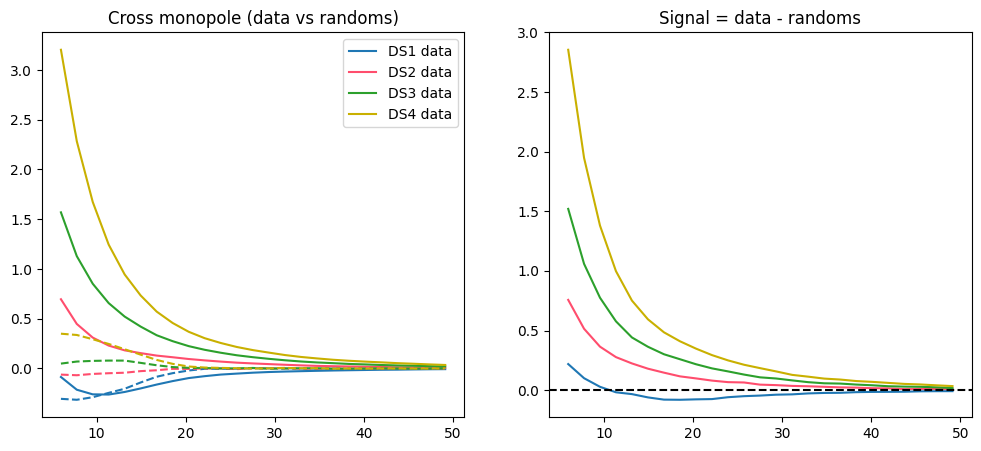

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for q in range(4):

    mono_data = get_block(mean_z, 2*q, nb)
    mono_rand = get_block(mean_rand, 2*q, nb)

    ax[0].plot(s, mono_data, color=colors[q], label=f"DS{q+1} data")
    ax[0].plot(s, mono_rand, "--", color=colors[q])

ax[0].set_title("Cross monopole (data vs randoms)")
ax[0].legend()

# différence → DOIT être significative
for q in range(4):

    diff = get_block(mean_z - mean_rand, 2*q, nb)

    ax[1].plot(s, diff, color=colors[q], label=f"DS{q+1}")

ax[1].set_title("Signal = data - randoms")
ax[1].axhline(0, color="k", ls="--")

plt.show()

Index(['root', 'notes', 'omega_b', 'omega_cdm', 'h', 'A_s', 'n_s', 'alpha_s',
       'N_ur', 'N_ncdm', 'omega_ncdm', 'w0_fld', 'wa_fld', 'sigma8_m',
       'sigma8_cb'],
      dtype='str')
pname and delta omega_b 0.0008899999999999984
pname and delta omega_cdm 0.007900000000000004
pname and delta n_s 0.020000000000000018
pname and delta sigma8 0.032147999999999954


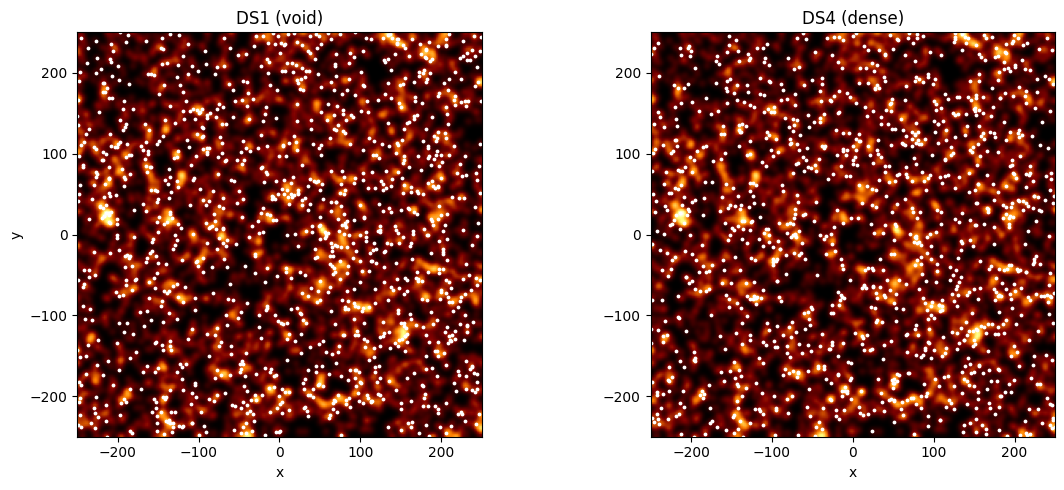

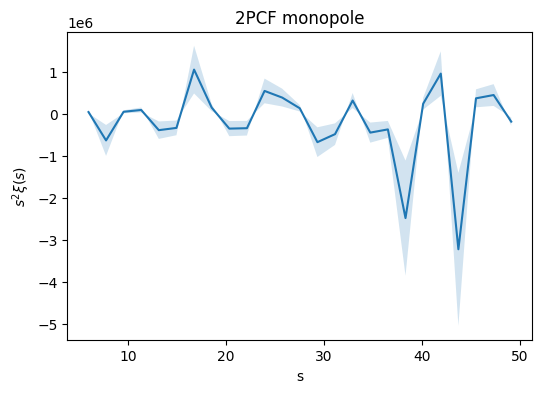

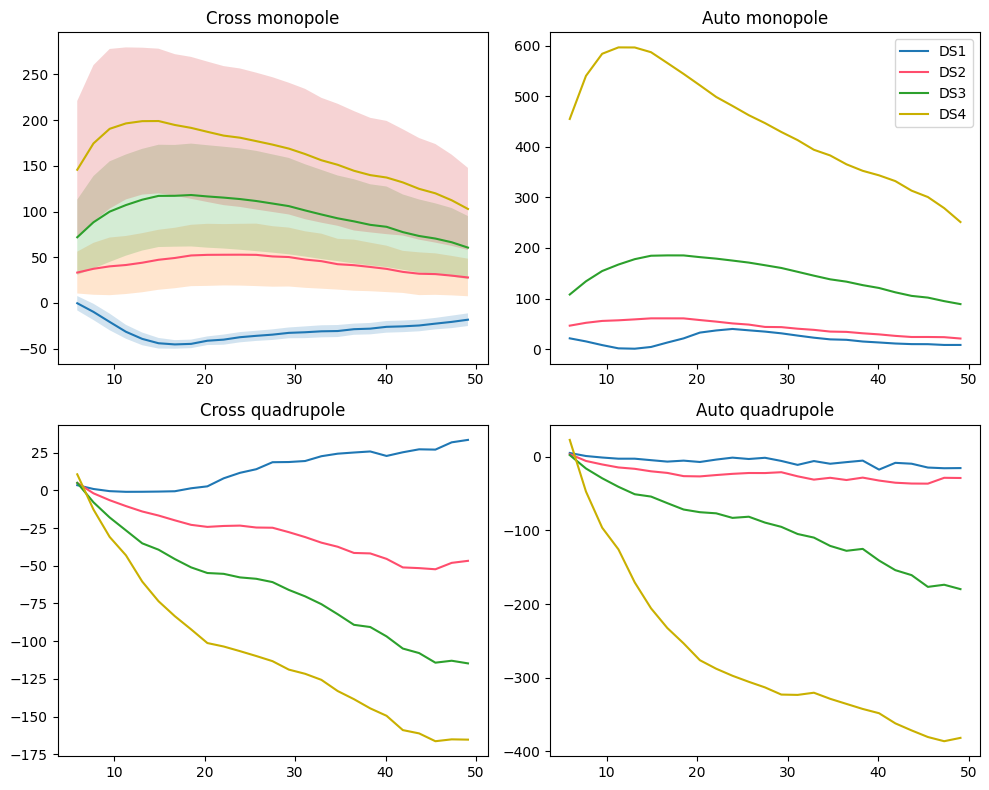

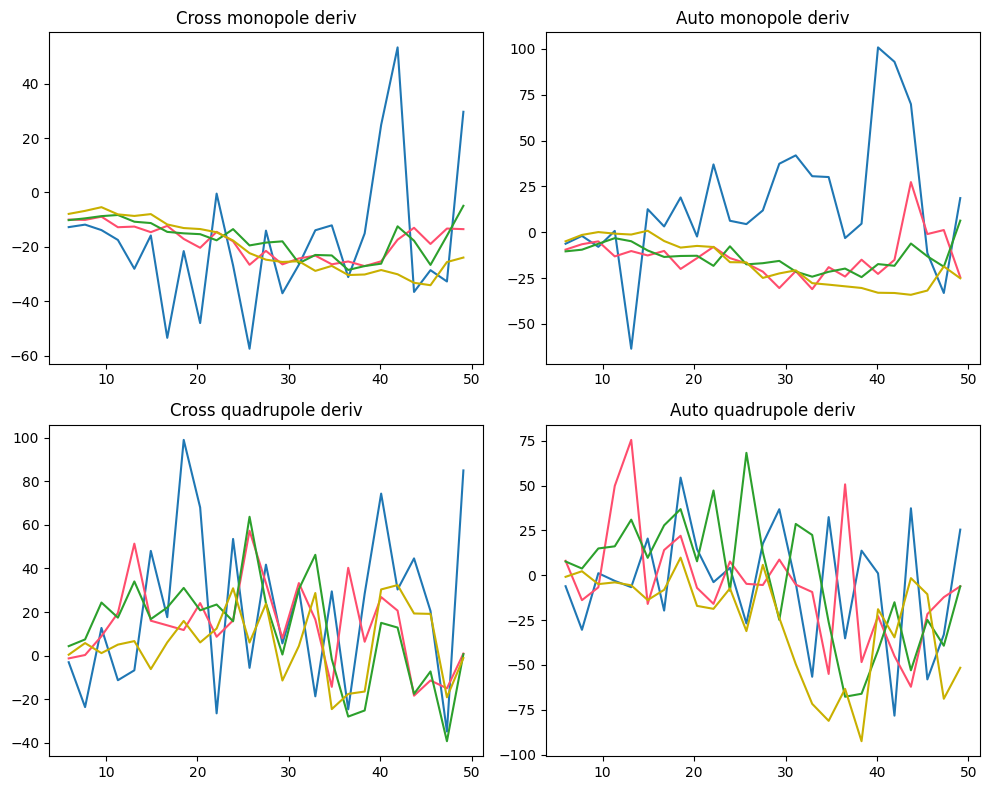

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
import pandas as pd


# ============================================================
# LOAD
# ============================================================

data_cov   = np.load("dataset_covariance_astra_100_1_2000.npz", allow_pickle=True)
data_deriv = np.load("dataset_derivatives_astra_20_1_2000.npz", allow_pickle=True)
COSMOLOGY_FILE = "/global/homes/h/hugon/home/acm/nb/cosmologies.csv"

cosmo_df = pd.read_csv(COSMOLOGY_FILE)
cosmo_df.columns = cosmo_df.columns.str.strip()
cosmo_df["cosmo_id"] = cosmo_df["root"].str.extract(r"cosm(\d+)").astype(int)
cosmo_df = cosmo_df.set_index("cosmo_id")

print(cosmo_df.columns)


FID_COSMO = 0

# ============================================================
# HELPERS
# ============================================================

def stack(arr):
    return np.vstack([np.asarray(x, dtype=float) for x in arr])

def group_by_cosmo(data):
    grouped = {}
    for i, cid in enumerate(data["cosmo_id"]):
        grouped.setdefault(int(cid), []).append(i)
    return grouped

def get_block(vec, i, nb):
    return vec[i*nb:(i+1)*nb]

# ============================================================
# BASIC ARRAYS
# ============================================================

s  = np.asarray(data_cov["s"][0], dtype=float)
nb = len(s)

group_cov = group_by_cosmo(data_cov)
idx_fid = group_cov[FID_COSMO]

# ============================================================
# ==================== RANDOM NORMALIZATION ===================
# ============================================================

rr = stack(data_cov["rr_pcf"][idx_fid]).mean(axis=0)

# ============================================================
# ==================== 2PCF ===============================
# ============================================================

X = stack(data_cov["pcf"][idx_fid])

mean_pcf = X.mean(axis=0) / (rr + 1e-8)
std_pcf  = X.std(axis=0)  / (rr + 1e-8)

# ============================================================
# ==================== DS MEAN ================================
# ============================================================

ds_z = stack(data_cov["ds_z"][idx_fid])
ds_r = stack(data_cov["ds_r"][idx_fid])

mean_z = ds_z.mean(axis=0)
std_z  = ds_z.std(axis=0)

mean_r = ds_r.mean(axis=0)
std_r  = ds_r.std(axis=0)

# ============================================================
# ==================== DERIVATIVES ============================
# ============================================================

group_deriv = group_by_cosmo(data_deriv)

pairs = {
    "omega_b": (100, 101),
    "omega_cdm": (102, 103),
    "n_s": (104, 105),
    "sigma8": (112, 113),
}

PARAM_MAP = {
    "omega_b": "omega_b",
    "omega_cdm": "omega_cdm",
    "n_s": "n_s",
    "sigma8": "sigma8_cb",
}

derivatives = {}

for pname, (cp, cm) in pairs.items():

    if cp not in group_deriv or cm not in group_deriv:
        continue

    col = PARAM_MAP[pname]

    if col not in cosmo_df.columns:
        print(f"Missing {col}, skipping {pname}")
        continue

    Xp = stack(data_deriv["ds_z"][group_deriv[cp]]).mean(axis=0)
    Xm = stack(data_deriv["ds_z"][group_deriv[cm]]).mean(axis=0)

    delta = cosmo_df.loc[cp, col] - cosmo_df.loc[cm, col]

    print("pname and delta", pname, delta)

    derivatives[pname] = (Xp - Xm) / delta

# ============================================================
# ==================== FIGURE 1 (DENSITY FIELD) ===============
# ============================================================

def density_field(positions, L=250, npix=256):

    H, _, _ = np.histogram2d(
        positions[:,0],
        positions[:,1],
        bins=npix,
        range=[[-L, L], [-L, L]]
    )

    H = ndi.gaussian_filter(H, sigma=2)
    return H

pos = np.asarray(data_cov["pos_sample"][0])
lab = np.asarray(data_cov["label_r"][0])[:len(pos)]

field = density_field(pos)

fig, axes = plt.subplots(1,2, figsize=(12,5))

for ax, q, title in zip(axes, [0,3], ["DS1 (void)", "DS4 (dense)"]):

    mask = lab == q

    ax.imshow(field.T, origin="lower",
              extent=[-250,250,-250,250],
              cmap="afmhot")

    ax.scatter(pos[mask,0], pos[mask,1], s=3, c="white")

    ax.set_title(title)

axes[0].set_ylabel("y")
axes[0].set_xlabel("x")
axes[1].set_xlabel("x")

plt.tight_layout()
plt.show()

# ============================================================
# ==================== FIGURE 2 (2PCF) ========================
# ============================================================

plt.figure(figsize=(6,4))
mono=mean_pcf[:nb]
err=std_pcf[:nb]
plt.plot(s, s**2 * mono)
plt.fill_between(s, s**2*(mono-err), s**2*(mono+err), alpha=0.2)

plt.title("2PCF monopole")
plt.xlabel("s")
plt.ylabel(r"$s^2 \xi(s)$")
plt.show()

# ============================================================
# ==================== FIGURE 3 (DS multipoles) ===============
# ============================================================

colors = ["#1f77b4","#ff4d6d","#2ca02c","#c9b000"]
labels = ["DS1","DS2","DS3","DS4"]

fig, ax = plt.subplots(2,2, figsize=(10,8))

# CROSS monopole
for q in range(4):
    mono = get_block(mean_z, 2*q, nb)
    err  = get_block(std_z, 2*q, nb)
    ax[0,0].plot(s, s**2 * mono, color=colors[q])
    ax[0,0].fill_between(s, s**2*(mono-err), s**2*(mono+err), alpha=0.2)

# AUTO monopole
for q in range(4):
    mono = get_block(mean_z, 8+2*q, nb)
    err  = get_block(std_z, 8+2*q, nb)
    ax[0,1].plot(s, s**2 * mono, color=colors[q], label=labels[q])

# CROSS quadrupole
for q in range(4):
    quad = get_block(mean_z, 2*q+1, nb)
    ax[1,0].plot(s, s**2 * quad, color=colors[q])

# AUTO quadrupole
for q in range(4):
    quad = get_block(mean_z, 8+2*q+1, nb)
    ax[1,1].plot(s, s**2 * quad, color=colors[q])

ax[0,1].legend()

ax[0,0].set_title("Cross monopole")
ax[0,1].set_title("Auto monopole")
ax[1,0].set_title("Cross quadrupole")
ax[1,1].set_title("Auto quadrupole")

plt.tight_layout()
plt.show()

# ============================================================
# ==================== FIGURE 4 (DERIVATIVES) ================
# ============================================================

pname = "omega_cdm"
D = derivatives[pname] / (std_z + 1e-8)

fig, ax = plt.subplots(2,2, figsize=(10,8))

for q in range(4):
    ax[0,0].plot(s, get_block(D,2*q,nb), color=colors[q])
    ax[1,0].plot(s, get_block(D,2*q+1,nb), color=colors[q])
    ax[0,1].plot(s, get_block(D,8+2*q,nb), color=colors[q])
    ax[1,1].plot(s, get_block(D,8+2*q+1,nb), color=colors[q])

ax[0,0].set_title("Cross monopole deriv")
ax[0,1].set_title("Auto monopole deriv")
ax[1,0].set_title("Cross quadrupole deriv")
ax[1,1].set_title("Auto quadrupole deriv")

plt.tight_layout()
plt.show()

In [2]:
def group_by_cosmo(data):

    grouped = {}

    for i in range(len(data["cosmo_id"])):

        cid = data["cosmo_id"][i]

        if cid not in grouped:
            grouped[cid] = []

        grouped[cid].append(i)

    return grouped


def compute_mean_vector(data, indices, key="pcf"):

    vecs = np.stack([data[key][i] for i in indices])

    return vecs.mean(axis=0)



In [ ]:
grouped = group_by_cosmo(data_deriv)

# fiducial
xi_fid = compute_mean_vector(data_deriv, grouped[FID_COSMO])

derivatives = {}

pairs = {
    "omega_b": (100, 101),
    "omega_cdm": (102, 103),
    "n_s": (104, 105),
    "sigma8": (112, 113),
}

for pname, (cp, cm) in pairs.items():

    xi_plus  = compute_mean_vector(data_deriv, grouped[cp])
    xi_minus = compute_mean_vector(data_deriv, grouped[cm])

    theta_plus  = cosmo_df.loc[cp, pname]
    theta_minus = cosmo_df.loc[cm, pname]

    dtheta = theta_plus - theta_minus

    deriv = (xi_plus - xi_minus) / dtheta

    derivatives[pname] = deriv

grouped_cov = group_by_cosmo(data_cov)

indices = grouped_cov[FID_COSMO]

vecs = np.stack([data_cov["pcf"][i] for i in indices])

cov = np.cov(vecs, rowvar=False)

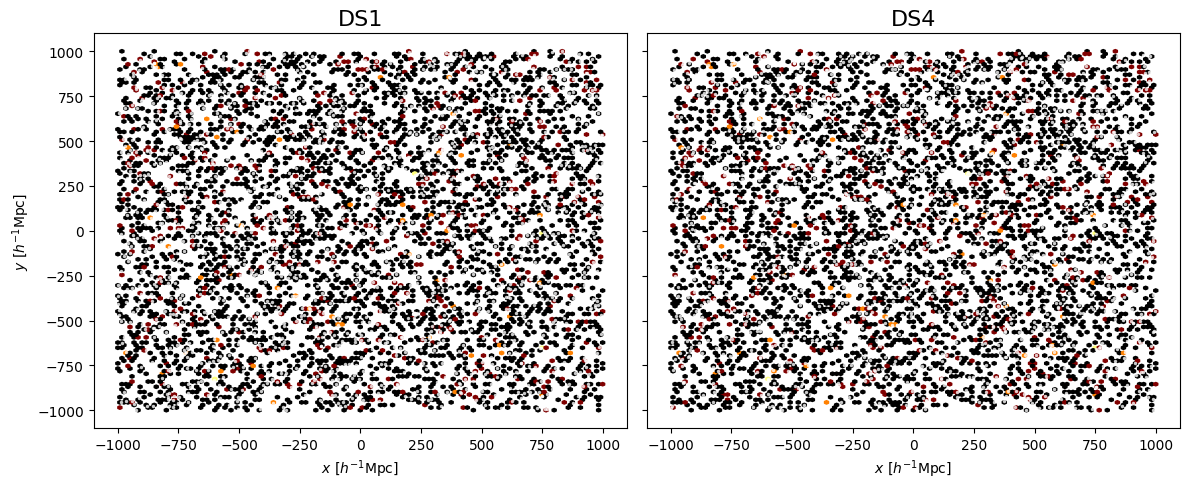

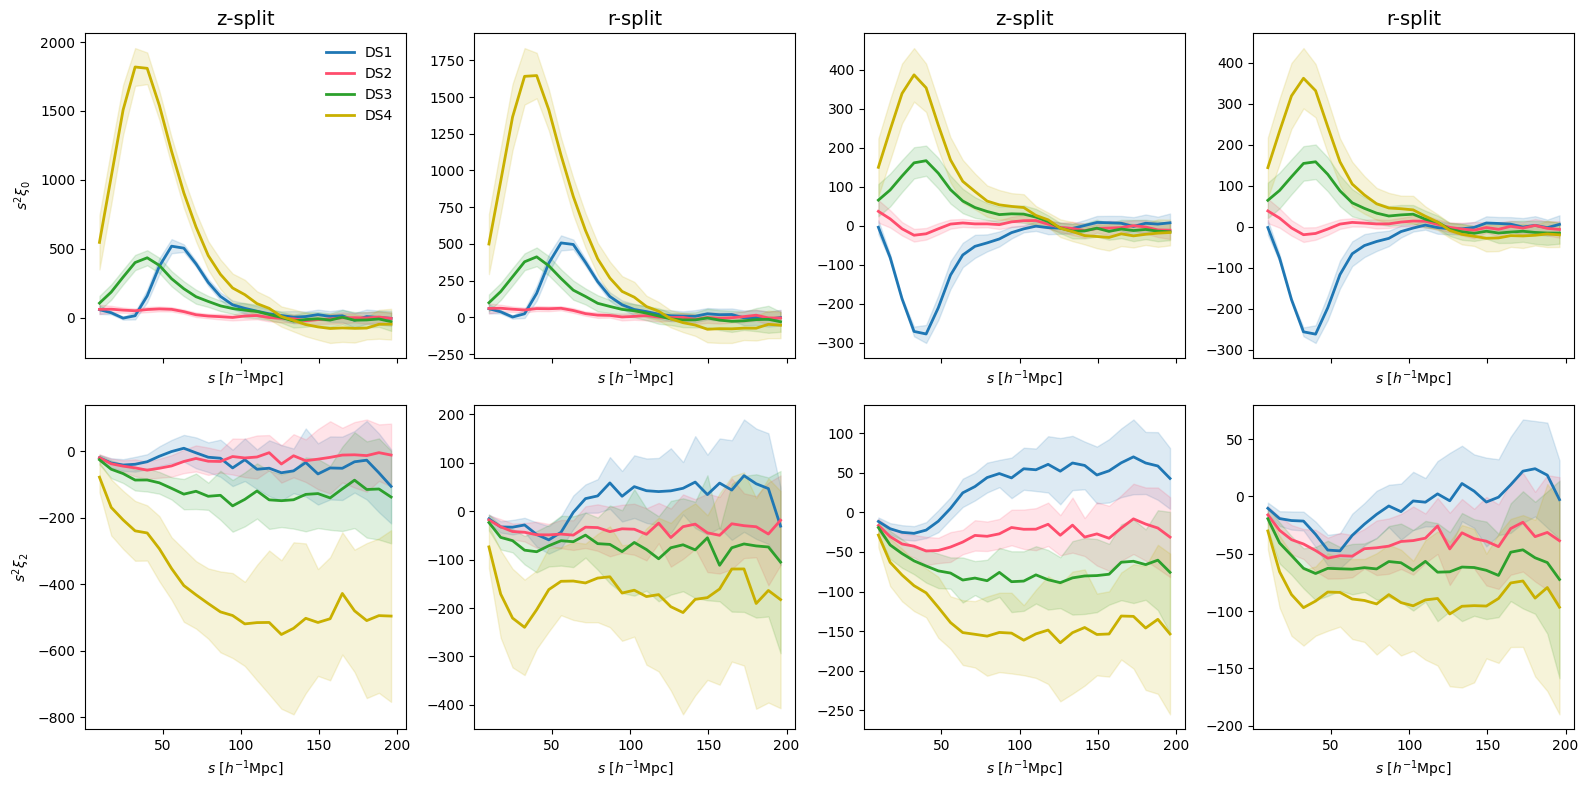

In [6]:
# ============================================================
# FIGURES 1 and 3 from your saved datasets
# Compatible with your current object-array .npz structure
# ============================================================


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def stack_obj(arr):
    return np.vstack([np.asarray(x) for x in arr])

def cat_obj(arr):
    return np.concatenate([np.asarray(x) for x in arr])

# ============================================================
# FIGURE 1
# DS1 vs DS4 projected positions
# ============================================================

# take first mock only (cleanest visual)
pos = np.asarray(data_cov["pos_sample"][0])      # (5000,3)
lab = np.asarray(data_cov["label_r"][0])[:len(pos)]

# DS1 = label 0 , DS4 = label 3
mask1 = lab == 0
mask4 = lab == 3

fig, axes = plt.subplots(1,2, figsize=(12,5), sharex=True, sharey=True)

for ax, mask, title in zip(
    axes,
    [mask1, mask4],
    ["DS1", "DS4"]
):

    # background projected density
    ax.hexbin(
        pos[:,0], pos[:,1],
        gridsize=120,
        cmap="afmhot",
        mincnt=1
    )

    # overlay quintile centres
    ax.scatter(
        pos[mask,0],
        pos[mask,1],
        s=6,
        c="white",
        alpha=0.8,
        linewidths=0
    )

    ax.set_title(title, fontsize=16)
    ax.set_xlabel(r"$x\ [h^{-1}{\rm Mpc}]$")

axes[0].set_ylabel(r"$y\ [h^{-1}{\rm Mpc}]$")

plt.tight_layout()
plt.show()



# ============================================================
# FIGURE 3
# Multipoles of DS auto / DS-halo cross correlations
# ============================================================


# your vector structure:
# 4 quintiles cross monopole/quadrupole
# 4 quintiles auto monopole/quadrupole
# total = 16 blocks of len(s)

nb = len(s)

def get_block(vec, i, nb):
    lo = i * nb
    hi = (i + 1) * nb
    return np.asarray(vec[lo:hi], dtype=np.float64)

colors = [
    "#1f77b4",   # DS1 blue
    "#ff4d6d",   # DS2 red
    "#2ca02c",   # DS3 green
    "#c9b000",   # DS4 gold
]

labels = ["DS1","DS2","DS3","DS4"]

fig, ax = plt.subplots(2,4, figsize=(16,8), sharex=True)

# ------------------------------------------------------------
# LEFT PANEL = AUTO
# ------------------------------------------------------------
# z-split
for q in range(4):

    mono = get_block(mean_z, 8 + 2*q, nb)
    quad = get_block(mean_z, 8 + 2*q + 1, nb)

    em = get_block(std_z, 8 + 2*q, nb)
    eq = get_block(std_z, 8 + 2*q + 1, nb)

    ax[0,0].plot(s, s**2 * mono, color=colors[q], lw=2, label=labels[q])
    ax[0,0].fill_between(s, s**2*(mono-em), s**2*(mono+em),
                         color=colors[q], alpha=0.15)

    ax[1,0].plot(s, s**2 * quad, color=colors[q], lw=2)
    ax[1,0].fill_between(s, s**2*(quad-eq), s**2*(quad+eq),
                         color=colors[q], alpha=0.15)

# r-split
for q in range(4):

    mono = get_block(mean_r, 8 + 2*q, nb)
    quad = get_block(mean_r, 8 + 2*q + 1, nb)

    em = get_block(std_r, 8 + 2*q, nb)
    eq = get_block(std_r, 8 + 2*q + 1, nb)

    ax[0,1].plot(s, s**2 * mono, color=colors[q], lw=2)
    ax[0,1].fill_between(s, s**2*(mono-em), s**2*(mono+em),
                         color=colors[q], alpha=0.15)

    ax[1,1].plot(s, s**2 * quad, color=colors[q], lw=2)
    ax[1,1].fill_between(s, s**2*(quad-eq), s**2*(quad+eq),
                         color=colors[q], alpha=0.15)

# ------------------------------------------------------------
# RIGHT PANEL = CROSS
# ------------------------------------------------------------
# z-split
for q in range(4):

    mono = get_block(mean_z, 2*q, nb)
    quad = get_block(mean_z, 2*q + 1, nb)

    em = get_block(std_z, 2*q, nb)
    eq = get_block(std_z, 2*q + 1, nb)

    ax[0,2].plot(s, s**2 * mono, color=colors[q], lw=2)
    ax[0,2].fill_between(s, s**2*(mono-em), s**2*(mono+em),
                         color=colors[q], alpha=0.15)

    ax[1,2].plot(s, s**2 * quad, color=colors[q], lw=2)
    ax[1,2].fill_between(s, s**2*(quad-eq), s**2*(quad+eq),
                         color=colors[q], alpha=0.15)

# r-split
for q in range(4):

    mono = get_block(mean_r, 2*q, nb)
    quad = get_block(mean_r, 2*q + 1, nb)

    em = get_block(std_r, 2*q, nb)
    eq = get_block(std_r, 2*q + 1, nb)

    ax[0,3].plot(s, s**2 * mono, color=colors[q], lw=2)
    ax[0,3].fill_between(s, s**2*(mono-em), s**2*(mono+em),
                         color=colors[q], alpha=0.15)

    ax[1,3].plot(s, s**2 * quad, color=colors[q], lw=2)
    ax[1,3].fill_between(s, s**2*(quad-eq), s**2*(quad+eq),
                         color=colors[q], alpha=0.15)

# ------------------------------------------------------------
# cosmetics
# ------------------------------------------------------------
titles = ["z-split", "r-split", "z-split", "r-split"]

for j in range(4):
    ax[0,j].set_title(titles[j], fontsize=14)

for i in range(2):
    for j in range(4):
        ax[i,j].set_xlabel(r"$s\ [h^{-1}{\rm Mpc}]$")

ax[0,0].set_ylabel(r"$s^2 \xi_0$")
ax[1,0].set_ylabel(r"$s^2 \xi_2$")

ax[0,0].legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

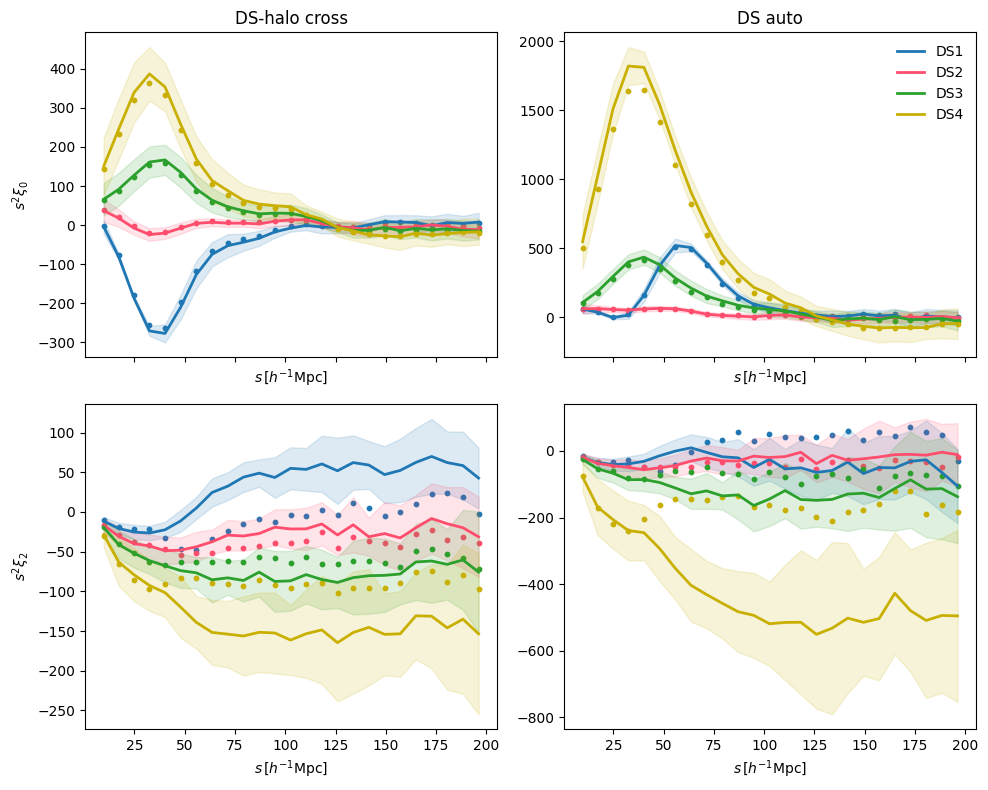

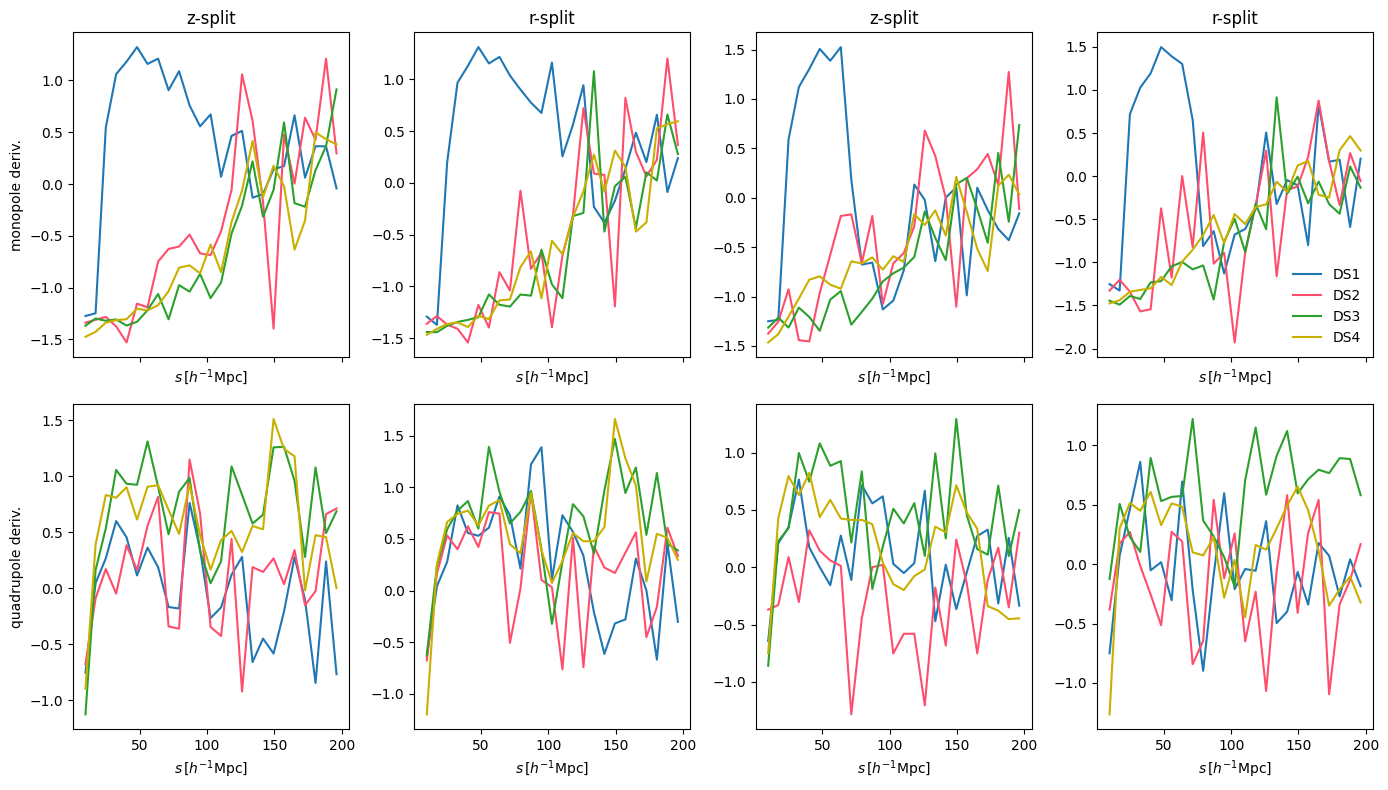

In [1]:
# ============================================================
# FIGURES 4 and 5
# using:
#   data_cov   = covariance mocks
#   data_deriv = cosmology variations
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

data_cov   = np.load("dataset_covariance_astra_30_20.npz", allow_pickle=True)
data_deriv = np.load("dataset_derivatives_astra_3_20.npz", allow_pickle=True)

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------

def stack_float(obj):
    return np.vstack([np.asarray(x, dtype=float) for x in obj])

def vec(obj):
    return np.asarray(obj, dtype=float)

def block(v, i, nb):
    return np.asarray(v[i*nb:(i+1)*nb], dtype=float)

# ------------------------------------------------------------
# load vectors
# ------------------------------------------------------------

s   = vec(data_cov["s"][0])
nb  = len(s)

dsz = stack_float(data_cov["ds_z"])
dsr = stack_float(data_cov["ds_r"])

mean_z = dsz.mean(axis=0)
std_z  = dsz.std(axis=0)

mean_r = dsr.mean(axis=0)
std_r  = dsr.std(axis=0)

colors = ["#1f77b4","#ff4d6d","#2ca02c","#c9b000"]
labels = ["DS1","DS2","DS3","DS4"]

# ============================================================
# FIGURE 4
# dots = r-split
# lines = recon-split (= z-split here)
# left = cross
# right = auto
# ============================================================

fig, ax = plt.subplots(2,2, figsize=(10,8), sharex=True)

# ---------------- top-left : CROSS monopole
for q in range(4):

    iz0 = 2*q
    ir0 = 2*q

    vz = block(mean_z, iz0, nb)
    vr = block(mean_r, ir0, nb)
    ez = block(std_z , iz0, nb)

    ax[0,0].plot(s, s**2*vz, color=colors[q], lw=2)
    ax[0,0].scatter(s, s**2*vr, color=colors[q], s=10)

    ax[0,0].fill_between(
        s, s**2*(vz-ez), s**2*(vz+ez),
        color=colors[q], alpha=0.15
    )

# ---------------- bottom-left : CROSS quadrupole
for q in range(4):

    iz2 = 2*q+1
    ir2 = 2*q+1

    vz = block(mean_z, iz2, nb)
    vr = block(mean_r, ir2, nb)
    ez = block(std_z , iz2, nb)

    ax[1,0].plot(s, s**2*vz, color=colors[q], lw=2)
    ax[1,0].scatter(s, s**2*vr, color=colors[q], s=10)

    ax[1,0].fill_between(
        s, s**2*(vz-ez), s**2*(vz+ez),
        color=colors[q], alpha=0.15
    )

# ---------------- top-right : AUTO monopole
for q in range(4):

    iz0 = 8 + 2*q
    ir0 = 8 + 2*q

    vz = block(mean_z, iz0, nb)
    vr = block(mean_r, ir0, nb)
    ez = block(std_z , iz0, nb)

    ax[0,1].plot(s, s**2*vz, color=colors[q], lw=2, label=labels[q])
    ax[0,1].scatter(s, s**2*vr, color=colors[q], s=10)

    ax[0,1].fill_between(
        s, s**2*(vz-ez), s**2*(vz+ez),
        color=colors[q], alpha=0.15
    )

# ---------------- bottom-right : AUTO quadrupole
for q in range(4):

    iz2 = 8 + 2*q + 1
    ir2 = 8 + 2*q + 1

    vz = block(mean_z, iz2, nb)
    vr = block(mean_r, ir2, nb)
    ez = block(std_z , iz2, nb)

    ax[1,1].plot(s, s**2*vz, color=colors[q], lw=2)
    ax[1,1].scatter(s, s**2*vr, color=colors[q], s=10)

    ax[1,1].fill_between(
        s, s**2*(vz-ez), s**2*(vz+ez),
        color=colors[q], alpha=0.15
    )

# cosmetics
ax[0,0].set_title("DS-halo cross")
ax[0,1].set_title("DS auto")

ax[0,0].set_ylabel(r"$s^2\xi_0$")
ax[1,0].set_ylabel(r"$s^2\xi_2$")

for i in range(2):
    for j in range(2):
        ax[i,j].set_xlabel(r"$s\,[h^{-1}{\rm Mpc}]$")

ax[0,1].legend(frameon=False)
plt.tight_layout()
plt.show()



# ============================================================
# FIGURE 5
# derivatives wrt Omega_m
# use cosmo 102 / 103 as +/- omega_cdm proxy
# derivative = (plus - minus)/(2 delta)
# ============================================================

cid = data_deriv["cosmo_id"].astype(int)

plus  = cid == 100
minus = cid == 101

Xp_z = stack_float(data_deriv["ds_z"][plus])
Xm_z = stack_float(data_deriv["ds_z"][minus])

Xp_r = stack_float(data_deriv["ds_r"][plus])
Xm_r = stack_float(data_deriv["ds_r"][minus])

# mean over mocks
Xp_z = Xp_z.mean(axis=0)
Xm_z = Xm_z.mean(axis=0)

Xp_r = Xp_r.mean(axis=0)
Xm_r = Xm_r.mean(axis=0)

# finite difference (delta omitted -> shape only)
der_z = (Xp_z - Xm_z)/2
der_r = (Xp_r - Xm_r)/2

# normalize by covariance std
Dz = der_z / std_z
Dr = der_r / std_r

fig, ax = plt.subplots(2,4, figsize=(14,8), sharex=True)

# LEFT = cross
for q in range(4):

    # z split
    ax[0,0].plot(s, block(Dz,2*q,nb),   color=colors[q])
    ax[1,0].plot(s, block(Dz,2*q+1,nb), color=colors[q])

    # r split
    ax[0,1].plot(s, block(Dr,2*q,nb),   color=colors[q])
    ax[1,1].plot(s, block(Dr,2*q+1,nb), color=colors[q])

# RIGHT = auto
for q in range(4):

    # z split
    ax[0,2].plot(s, block(Dz,8+2*q,nb),   color=colors[q])
    ax[1,2].plot(s, block(Dz,8+2*q+1,nb), color=colors[q])

    # r split
    ax[0,3].plot(s, block(Dr,8+2*q,nb),   color=colors[q], label=labels[q])
    ax[1,3].plot(s, block(Dr,8+2*q+1,nb), color=colors[q])

titles = ["z-split","r-split","z-split","r-split"]

for j in range(4):
    ax[0,j].set_title(titles[j])

ax[0,0].set_ylabel("monopole deriv.")
ax[1,0].set_ylabel("quadrupole deriv.")

for i in range(2):
    for j in range(4):
        ax[i,j].set_xlabel(r"$s\,[h^{-1}{\rm Mpc}]$")

ax[0,3].legend(frameon=False)
plt.tight_layout()
plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def unpack(x):
    """
    Convertit ton format object-array -> array exploitable.
    Cas possibles:
    - (N,) object où chaque élément est (M,) ou (M,3)
    """
    x = np.asarray(x, dtype=object)

    # cas normal déjà stackable
    try:
        return np.vstack(x)
    except:
        return np.array([np.asarray(i) for i in x])


def flat(x):
    """
    pour labels ou scalaires stockés en object arrays
    """
    x = np.asarray(x, dtype=object)
    if x.ndim == 1:
        return np.concatenate([np.atleast_1d(i) for i in x])
    return np.asarray(x)

In [25]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("dataset_covariance_astra_30_20.npz", allow_pickle=True)

pos = np.vstack(data["pos_sample"])
label = np.concatenate([np.atleast_1d(x) for x in data["label_r"]])

mask_ds1 = (label == 0)   # DS1 (most underdense)
mask_ds4 = (label == 3)   # DS4 (most overdense)

In [29]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("dataset_covariance_astra_30_20.npz", allow_pickle=True)

pos = np.vstack(data["pos_sample"])

# IMPORTANT: reconstruire labels cohérents avec pos_sample
# (on prend label déjà subsamplé si présent)
label = np.concatenate([np.atleast_1d(x) for x in data["label_r"]])

print(pos.shape, label.shape)

(150000, 3) (6000000,)


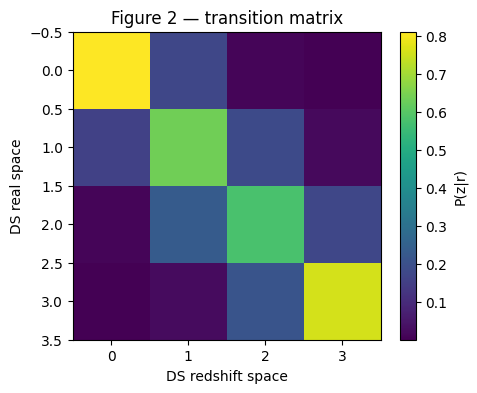

In [17]:
label_r = flat(data["label_r"]).astype(int)
label_z = flat(data["label_z"]).astype(int)
T = np.zeros((4,4))

for i in range(4):
    mask = (label_r == i)
    for j in range(4):
        T[i,j] = np.mean(label_z[mask] == j)

plt.figure(figsize=(5,4))
plt.imshow(T, cmap="viridis")
plt.colorbar(label="P(z|r)")
plt.xlabel("DS redshift space")
plt.ylabel("DS real space")
plt.title("Figure 2 — transition matrix")
plt.show()

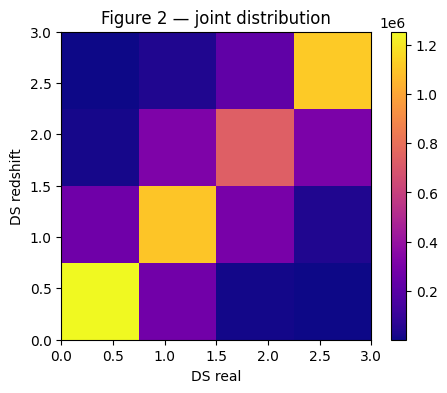

In [20]:
label_r = np.concatenate([
    np.atleast_1d(x) for x in data["label_r"]
]).astype(int)

label_z = np.concatenate([
    np.atleast_1d(x) for x in data["label_z"]
]).astype(int)
plt.figure(figsize=(5,4))
plt.hist2d(
    label_r,
    label_z,
    bins=[4,4],
    cmap="plasma"
)

plt.colorbar()
plt.xlabel("DS real")
plt.ylabel("DS redshift")
plt.title("Figure 2 — joint distribution")
plt.show()

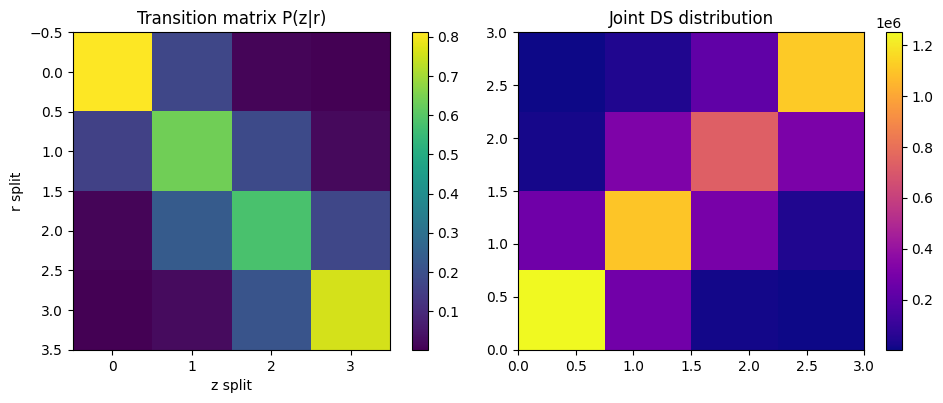

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# transition matrix
T = np.zeros((4,4))

for i in range(4):
    mask = (label_r == i)
    for j in range(4):
        T[i,j] = np.mean(label_z[mask] == j)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(T, cmap="viridis")
plt.colorbar()
plt.title("Transition matrix P(z|r)")
plt.xlabel("z split")
plt.ylabel("r split")

plt.subplot(1,2,2)
plt.hist2d(label_r, label_z, bins=[4,4], cmap="plasma")
plt.colorbar()
plt.title("Joint DS distribution")

plt.tight_layout()
plt.show()

positions: (5000, 3)
label_r: (5000,)
label_z: (5000,)
rvals_r: (5000,)

BASIC CHECKS
NaN rvals_r: 0
NaN rvals_z: 0
label_r bincount: [1289 1224 1260 1227]
label_z bincount: [1252 1272 1236 1240]
rvals_r min/max: -1.0 1.0
rvals_z min/max: -1.0 1.0


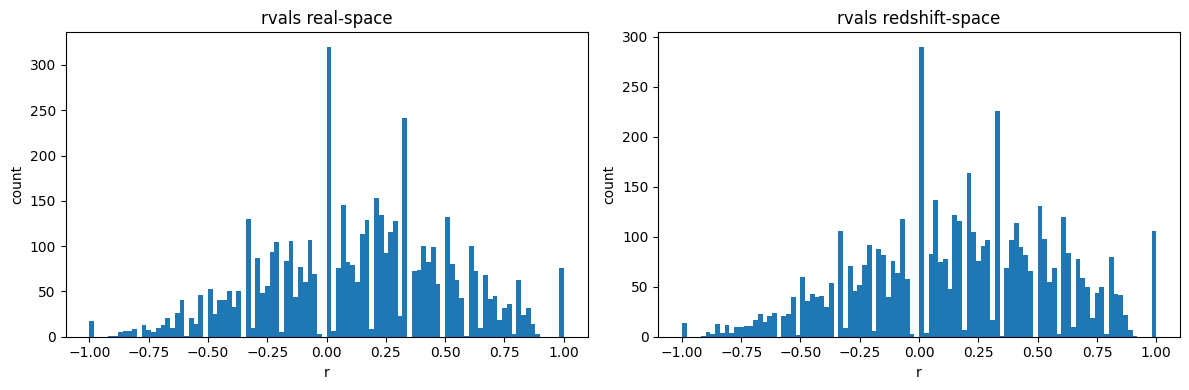


QUARTILE CUTS
real-space quantiles:
[-1.         -0.14285715  0.14285715  0.40000001  1.        ]

redshift-space quantiles:
[-1.         -0.125       0.17647059  0.45454547  1.        ]


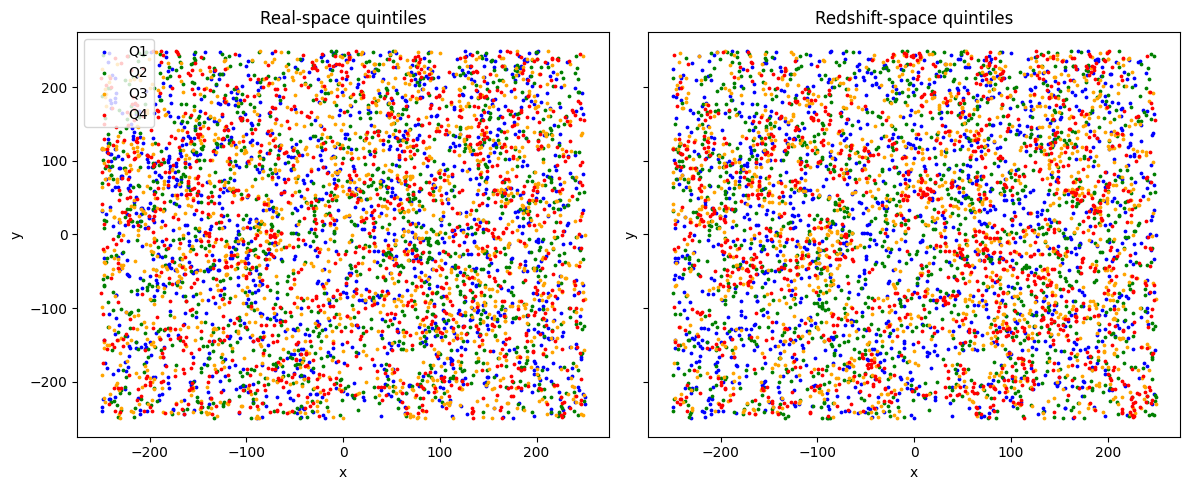


DISTANCE TO EDGE
min distance: 0.0088043212890625
max distance: 226.07925987243652


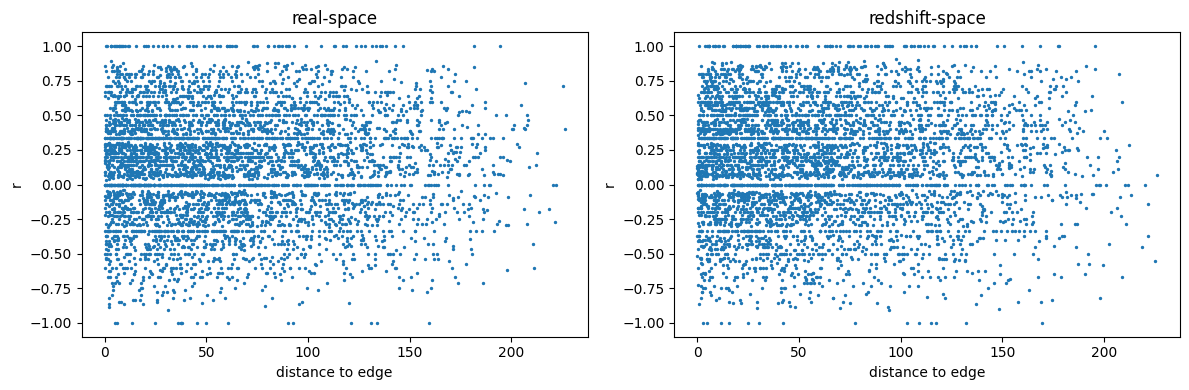

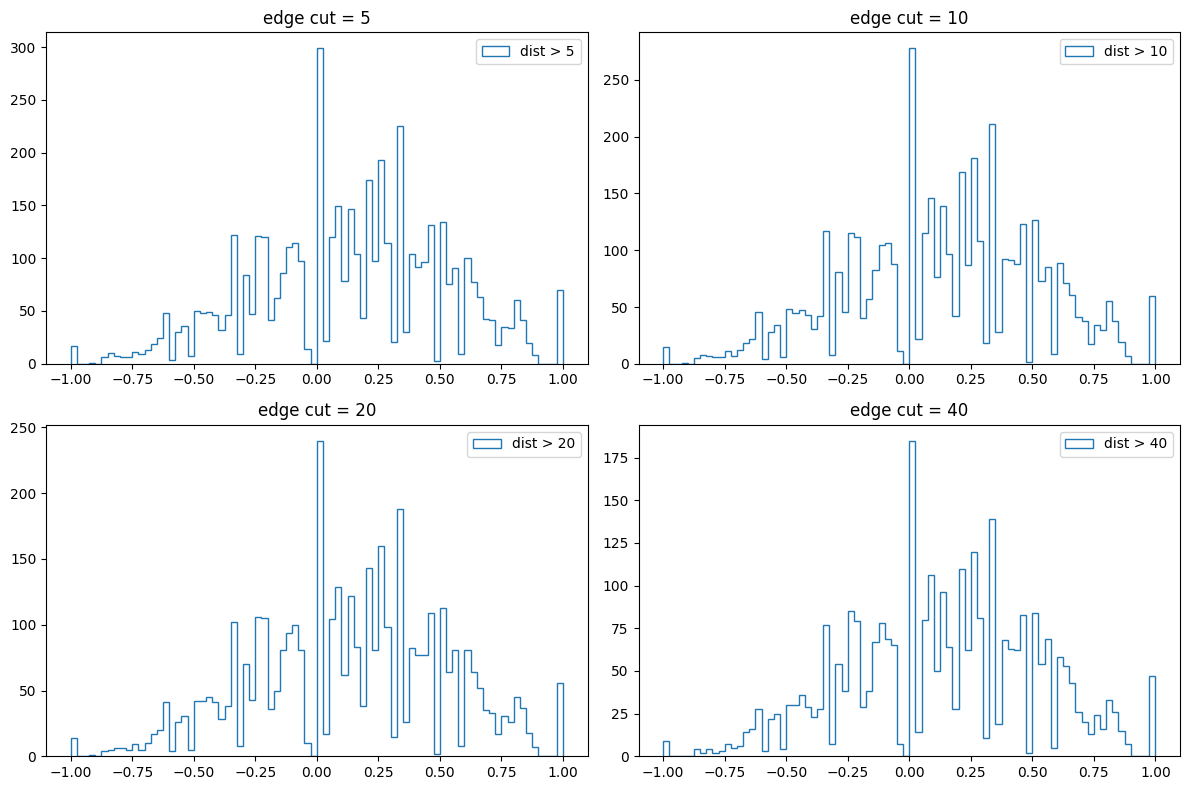


INNER SAMPLE
kept: 3952 / 5000
bincount inner: [1042  963  970  977]


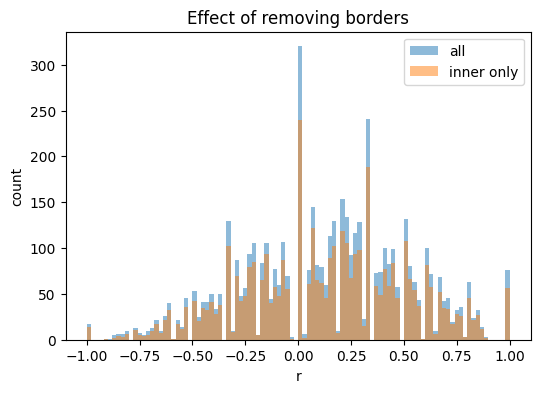

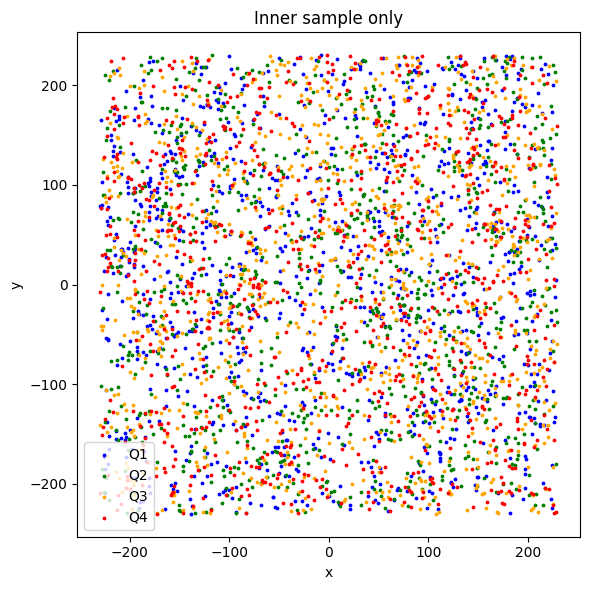


INTERPRETATION GUIDE

If the box cut introduces problems, you will typically observe:

1) distorted r histograms
2) strong pile-up near r = +/-1
3) spatial concentration of one class near boundaries
4) strong dependence of r on distance-to-edge
5) unstable bincounts after edge removal

If removing borders stabilizes the histograms and classes,
then ASTRA is strongly affected by boundary conditions.



In [11]:
# ============================================================
# ASTRA DEBUG NOTEBOOK
# Goal:
#   understand why the statistics change after reducing box size
#
# Tests:
#   1) r histogram
#   2) quintile counts
#   3) spatial visualization
#   4) distance-to-boundary effects
#   5) remove borders and recompute diagnostics
#
# Uses:
#   - small box dataset
#   - only first realization for clarity
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD
# ============================================================

data_cov   = np.load(
    "dataset_covariance_astra_32_1_250.npz",
    allow_pickle=True
)

# ============================================================
# SELECT FIRST REALIZATION
# ============================================================

i = 0

pos = np.asarray(data_cov["pos_sample"][i], dtype=float)

label_r = np.asarray(data_cov["label_r_sample"][i], dtype=int)
label_z = np.asarray(data_cov["label_z_sample"][i], dtype=int)

rvals_r = np.asarray(data_cov["rvals_r_sample"][i], dtype=float)
rvals_z = np.asarray(data_cov["rvals_z_sample"][i], dtype=float)

print("positions:", pos.shape)
print("label_r:", label_r.shape)
print("label_z:", label_z.shape)
print("rvals_r:", rvals_r.shape)

# ============================================================
# BASIC CHECKS
# ============================================================

print("\n==============================")
print("BASIC CHECKS")
print("==============================")

print("NaN rvals_r:", np.isnan(rvals_r).sum())
print("NaN rvals_z:", np.isnan(rvals_z).sum())

print("label_r bincount:", np.bincount(label_r))
print("label_z bincount:", np.bincount(label_z))

print("rvals_r min/max:", rvals_r.min(), rvals_r.max())
print("rvals_z min/max:", rvals_z.min(), rvals_z.max())

# ============================================================
# HISTOGRAMS
# ============================================================

fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].hist(rvals_r, bins=100)
ax[0].set_title("rvals real-space")

ax[1].hist(rvals_z, bins=100)
ax[1].set_title("rvals redshift-space")

for a in ax:
    a.set_xlabel("r")
    a.set_ylabel("count")

plt.tight_layout()
plt.show()

# ============================================================
# QUARTILE CUTS
# ============================================================

print("\n==============================")
print("QUARTILE CUTS")
print("==============================")

q_r = np.quantile(rvals_r, [0,0.25,0.5,0.75,1.0])
q_z = np.quantile(rvals_z, [0,0.25,0.5,0.75,1.0])

print("real-space quantiles:")
print(q_r)

print("\nredshift-space quantiles:")
print(q_z)

# ============================================================
# SPATIAL VISUALIZATION
# ============================================================

colors = ["blue", "green", "orange", "red"]

fig, ax = plt.subplots(1,2, figsize=(12,5), sharex=True, sharey=True)

for q in range(4):

    mask = label_r == q

    ax[0].scatter(
        pos[mask,0],
        pos[mask,1],
        s=3,
        color=colors[q],
        label=f"Q{q+1}"
    )

ax[0].set_title("Real-space quintiles")
ax[0].legend()

for q in range(4):

    mask = label_z == q

    ax[1].scatter(
        pos[mask,0],
        pos[mask,1],
        s=3,
        color=colors[q]
    )

ax[1].set_title("Redshift-space quintiles")

for a in ax:
    a.set_xlabel("x")
    a.set_ylabel("y")

plt.tight_layout()
plt.show()

# ============================================================
# DISTANCE TO BOUNDARY
# ============================================================

# assume box centered on 0
L = 250

dist_to_edge = np.minimum.reduce([
    L - np.abs(pos[:,0]),
    L - np.abs(pos[:,1]),
    L - np.abs(pos[:,2]),
])

print("\n==============================")
print("DISTANCE TO EDGE")
print("==============================")

print("min distance:", dist_to_edge.min())
print("max distance:", dist_to_edge.max())

# ============================================================
# RVALUE VS DISTANCE TO EDGE
# ============================================================

fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].scatter(
    dist_to_edge,
    rvals_r,
    s=2
)

ax[0].set_title("real-space")
ax[0].set_xlabel("distance to edge")
ax[0].set_ylabel("r")

ax[1].scatter(
    dist_to_edge,
    rvals_z,
    s=2
)

ax[1].set_title("redshift-space")
ax[1].set_xlabel("distance to edge")
ax[1].set_ylabel("r")

plt.tight_layout()
plt.show()

# ============================================================
# HISTOGRAMS BY DISTANCE
# ============================================================

thresholds = [5, 10, 20, 40]

fig, ax = plt.subplots(2,2, figsize=(12,8))

ax = ax.ravel()

for k, thr in enumerate(thresholds):

    mask = dist_to_edge > thr

    ax[k].hist(
        rvals_r[mask],
        bins=80,
        histtype="step",
        label=f"dist > {thr}"
    )

    ax[k].set_title(f"edge cut = {thr}")
    ax[k].legend()

plt.tight_layout()
plt.show()

# ============================================================
# REMOVE BORDERS
# ============================================================

EDGE_CUT = 20

mask_inner = dist_to_edge > EDGE_CUT

print("\n==============================")
print("INNER SAMPLE")
print("==============================")

print("kept:", mask_inner.sum(), "/", len(mask_inner))

pos_inner = pos[mask_inner]
r_inner = rvals_r[mask_inner]
lab_inner = label_r[mask_inner]

print("bincount inner:", np.bincount(lab_inner))

# ============================================================
# INNER HISTOGRAM
# ============================================================

plt.figure(figsize=(6,4))

plt.hist(rvals_r, bins=100, alpha=0.5, label="all")
plt.hist(r_inner, bins=100, alpha=0.5, label="inner only")

plt.xlabel("r")
plt.ylabel("count")
plt.legend()

plt.title("Effect of removing borders")

plt.show()

# ============================================================
# INNER SPATIAL MAP
# ============================================================

fig, ax = plt.subplots(figsize=(6,6))

for q in range(4):

    mask = lab_inner == q

    ax.scatter(
        pos_inner[mask,0],
        pos_inner[mask,1],
        s=3,
        color=colors[q],
        label=f"Q{q+1}"
    )

ax.legend()
ax.set_title("Inner sample only")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY
# ============================================================

print("\n==============================")
print("INTERPRETATION GUIDE")
print("==============================")

print("""
If the box cut introduces problems, you will typically observe:

1) distorted r histograms
2) strong pile-up near r = +/-1
3) spatial concentration of one class near boundaries
4) strong dependence of r on distance-to-edge
5) unstable bincounts after edge removal

If removing borders stabilizes the histograms and classes,
then ASTRA is strongly affected by boundary conditions.
""")

In [1]:
from pathlib import Path
import pandas as pd
from collections import defaultdict

# ============================================================
# BASE DIR
# ============================================================

BASE_DIR = Path("/pscratch/sd/n/ntbfin/emulator/hods/z0.5/yuan23_prior/")
COSMOLOGY_FILE = "/global/homes/h/hugon/home/acm/nb/cosmologies.csv"

# ============================================================
# COSMOLOGY SETUP
# ============================================================

cosmo_df = pd.read_csv(COSMOLOGY_FILE)
cosmo_df.columns = cosmo_df.columns.str.strip()
cosmo_df["cosmo_id"] = cosmo_df["root"].str.extract(r"cosm(\d+)").astype(int)
cosmo_df = cosmo_df.set_index("cosmo_id")

FID_COSMO = 0

COSMOS_VAR = [
    100, 101,
    102, 103,
    104, 105,
    112, 113
]

COSMOS_KEEP = set([FID_COSMO] + COSMOS_VAR)

# ============================================================
# DISCOVERY
# ============================================================

def get_all_hod_files(base_dir):

    rows = []

    for d in base_dir.glob("c*_ph*"):

        try:
            cosmo_id = int(d.name.split("_")[0][1:])
            phase_id = int(d.name.split("_ph")[1])
        except Exception:
            continue

        for seed_dir in d.glob("seed*"):

            try:
                seed_id = int(seed_dir.name.replace("seed", ""))
            except Exception:
                continue

            for f in seed_dir.glob("hod*.fits"):

                rows.append({
                    "file": f,
                    "cosmo_id": cosmo_id,
                    "phase_id": phase_id,
                    "seed_id": seed_id
                })

    return pd.DataFrame(rows)


df = get_all_hod_files(BASE_DIR)

# ============================================================
# FILTER COSMOLOGIES
# ============================================================

df = df[df["cosmo_id"].isin(COSMOS_KEEP)]

# ============================================================
# BASIC STATS
# ============================================================

print("\n==============================")
print("TOTAL FILES")
print("==============================")
print(len(df))

print("\n==============================")
print("FILES PER COSMOLOGY")
print("==============================")
print(df["cosmo_id"].value_counts().sort_index())

print("\n==============================")
print("FILES PER PHASE")
print("==============================")
print(df["phase_id"].value_counts().sort_index())

print("\n==============================")
print("FILES PER SEED")
print("==============================")
print(df["seed_id"].value_counts().sort_index())

# ============================================================
# CONSISTENCY CHECKS
# ============================================================

print("\n==============================")
print("CONSISTENCY CHECKS")
print("==============================")

# duplicates
dup = df.duplicated(subset=["file"]).sum()
print("Duplicate files:", dup)

# missing cosmologies
missing_cosmos = set(COSMOS_KEEP) - set(df["cosmo_id"].unique())
print("Missing cosmologies:", missing_cosmos)

# min/max per cosmology
print("\nRange per cosmology:")
for c in sorted(df["cosmo_id"].unique()):
    sub = df[df["cosmo_id"] == c]
    print(
        f"cosmo {c:4d} | "
        f"N={len(sub):5d} | "
        f"phases={sub['phase_id'].nunique():3d} | "
        f"seeds={sub['seed_id'].nunique():3d}"
    )

# ============================================================
# OPTIONAL: EXPECTED STRUCTURE CHECK
# ============================================================

print("\n==============================")
print("EXPECTED STRUCTURE CHECK")
print("==============================")

expected = df.groupby(["cosmo_id", "phase_id"])["seed_id"].nunique()

print("Seeds per (cosmo, phase):")
print(expected.value_counts().sort_index())


TOTAL FILES
4500

FILES PER COSMOLOGY
cosmo_id
0      500
100    500
101    500
102    500
103    500
104    500
105    500
112    500
113    500
Name: count, dtype: int64

FILES PER PHASE
phase_id
0    4500
Name: count, dtype: int64

FILES PER SEED
seed_id
0    4500
Name: count, dtype: int64

CONSISTENCY CHECKS
Duplicate files: 0
Missing cosmologies: set()

Range per cosmology:
cosmo    0 | N=  500 | phases=  1 | seeds=  1
cosmo  100 | N=  500 | phases=  1 | seeds=  1
cosmo  101 | N=  500 | phases=  1 | seeds=  1
cosmo  102 | N=  500 | phases=  1 | seeds=  1
cosmo  103 | N=  500 | phases=  1 | seeds=  1
cosmo  104 | N=  500 | phases=  1 | seeds=  1
cosmo  105 | N=  500 | phases=  1 | seeds=  1
cosmo  112 | N=  500 | phases=  1 | seeds=  1
cosmo  113 | N=  500 | phases=  1 | seeds=  1

EXPECTED STRUCTURE CHECK
Seeds per (cosmo, phase):
seed_id
1    9
Name: count, dtype: int64


In [2]:
from pathlib import Path
import pandas as pd
from collections import defaultdict

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path("/pscratch/sd/n/ntbfin/emulator/hods/z0.5/yuan23_prior/")
COSMOLOGY_FILE = "/global/homes/h/hugon/home/acm/nb/cosmologies.csv"

# ============================================================
# LOAD COSMO TABLE
# ============================================================

cosmo_df = pd.read_csv(COSMOLOGY_FILE)
cosmo_df.columns = cosmo_df.columns.str.strip()
cosmo_df["cosmo_id"] = cosmo_df["root"].str.extract(r"cosm(\d+)").astype(int)
cosmo_df = cosmo_df.set_index("cosmo_id")

valid_cosmos = set(cosmo_df.index)

# ============================================================
# FILE PARSER
# ============================================================

def parse_files(base_dir):

    rows = []

    for d in base_dir.glob("c*_ph*"):

        try:
            cosmo_id = int(d.name.split("_")[0][1:])
            phase_id = int(d.name.split("_ph")[1])
        except Exception:
            continue

        for seed_dir in d.glob("seed*"):

            try:
                seed_id = int(seed_dir.name.replace("seed", ""))
            except Exception:
                continue

            for f in seed_dir.glob("hod*.fits"):

                rows.append((cosmo_id, phase_id, seed_id, str(f)))

    return rows


files = parse_files(BASE_DIR)

# ============================================================
# BASIC STATS
# ============================================================

print("\n==============================")
print("TOTAL FILES")
print("==============================")
print(len(files))

df = pd.DataFrame(files, columns=["cosmo", "phase", "seed", "file"])

# ============================================================
# FILTER VALID COSMOLOGIES
# ============================================================

df = df[df["cosmo"].isin(valid_cosmos)]

# ============================================================
# GLOBAL STATS
# ============================================================

print("\n==============================")
print("FILES PER COSMOLOGY")
print("==============================")
print(df["cosmo"].value_counts().sort_index())

print("\n==============================")
print("FILES PER PHASE")
print("==============================")
print(df["phase"].value_counts().sort_index())

print("\n==============================")
print("FILES PER SEED")
print("==============================")
print(df["seed"].value_counts().sort_index())

# ============================================================
# COMBINATIONS ANALYSIS
# ============================================================

combo_counts = df.groupby(["cosmo", "phase", "seed"]).size()

print("\n==============================")
print("UNIQUE (cosmo, phase, seed) COMBINATIONS")
print("==============================")
print("Total unique combos =", len(combo_counts))

print("\nMin samples per combo =", combo_counts.min())
print("Max samples per combo =", combo_counts.max())
print("Mean samples per combo =", combo_counts.mean())

# ============================================================
# MAX USABLE FOR COVARIANCE
# ============================================================

fid_cosmo = 0

fid_df = df[df["cosmo"] == fid_cosmo]

fid_combo_counts = fid_df.groupby(["phase", "seed"]).size()

print("\n==============================")
print("FIDUCIAL STRUCTURE")
print("==============================")
print("Fiducial files =", len(fid_df))
print("Unique (phase, seed) =", len(fid_combo_counts))

print("Samples per (phase, seed):")
print(fid_combo_counts.sort_values(ascending=False))

# ============================================================
# MAXIMUM BALANCED SAMPLE ESTIMATE
# ============================================================

min_per_combo = fid_combo_counts.min()
n_combos = len(fid_combo_counts)

max_balanced_samples = min_per_combo * n_combos

print("\n==============================")
print("MAX BALANCED COVARIANCE ESTIMATE")
print("==============================")
print("Min per (phase, seed) =", min_per_combo)
print("Number of combos =", n_combos)
print("Max balanced covariance size =", max_balanced_samples)

# ============================================================
# CHECK COVERAGE OF PHASE / SEED SPACE
# ============================================================

print("\n==============================")
print("PHASE / SEED COVERAGE")
print("==============================")
print("Unique phases =", df["phase"].nunique())
print("Unique seeds  =", df["seed"].nunique())

print("\nCross table (phase vs seed counts):")
print(pd.crosstab(df["phase"], df["seed"]))

# ============================================================
# SUMMARY
# ============================================================

print("\n==============================")
print("SUMMARY")
print("==============================")

print(f"Total files usable       : {len(df)}")
print(f"Fiducial usable files    : {len(fid_df)}")
print(f"Unique combos (cosmo, phase, seed): {df[['cosmo','phase','seed']].drop_duplicates().shape[0]}")
print(f"Max balanced covariance  : {max_balanced_samples}")


TOTAL FILES
42500

FILES PER COSMOLOGY
cosmo
0      500
1      500
2      500
3      500
4      500
      ... 
177    500
178    500
179    500
180    500
181    500
Name: count, Length: 85, dtype: int64

FILES PER PHASE
phase
0    42500
Name: count, dtype: int64

FILES PER SEED
seed
0    42500
Name: count, dtype: int64

UNIQUE (cosmo, phase, seed) COMBINATIONS
Total unique combos = 85

Min samples per combo = 500
Max samples per combo = 500
Mean samples per combo = 500.0

FIDUCIAL STRUCTURE
Fiducial files = 500
Unique (phase, seed) = 1
Samples per (phase, seed):
phase  seed
0      0       500
dtype: int64

MAX BALANCED COVARIANCE ESTIMATE
Min per (phase, seed) = 500
Number of combos = 1
Max balanced covariance size = 500

PHASE / SEED COVERAGE
Unique phases = 1
Unique seeds  = 1

Cross table (phase vs seed counts):
seed       0
phase       
0      42500

SUMMARY
Total files usable       : 42500
Fiducial usable files    : 500
Unique combos (cosmo, phase, seed): 85
Max balanced covaria